In [110]:
# §3.2 — Dependencies and Logging Setup
# ═══════════════════════════════════════════════════════════════════════════

# Standard library
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional, Set, Tuple, Union
from collections import Counter

# Numerical stack
import numpy as np
import pandas as pd

# Scientific
from scipy import stats
from scipy.stats import spearmanr

# Machine learning
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Hyperparameter optimisation
import optuna

# Portfolio optimisation
import pulp

# HTTP client for FPL API
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Interactive widgets and display
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown, clear_output

# Optional: Joblib for scaler persistence
import joblib


# ─── Logging configuration ─────────────────────────────────────────────────
# Mirrors Notebook 1 and 2 convention: ISO-8601 timestamp | level | message.
# Level defaults to INFO; debug-level noise from matplotlib/optuna is silenced.

logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
    force=True,
)
log = logging.getLogger("forecaster_pro")

# Silence known-verbose third-party loggers
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Suppress known-harmless warnings that clutter the notebook
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")


# ─── Global reproducibility seed ───────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


# ─── Version reporting ─────────────────────────────────────────────────────
def _report_versions() -> None:
    """Logs dependency versions for thesis reproducibility."""
    import sklearn
    versions = {
        "Python":          f"{__import__('sys').version.split()[0]}",
        "pandas":          pd.__version__,
        "numpy":           np.__version__,
        "lightgbm":        lgb.__version__,
        "scikit-learn":    sklearn.__version__,
        "optuna":          optuna.__version__,
        "pulp":            pulp.__version__,
        "matplotlib":      plt.matplotlib.__version__,
        "scipy":           __import__("scipy").__version__,
    }
    log.info("─" * 60)
    log.info("Forecaster Pro — dependency versions")
    log.info("─" * 60)
    for pkg, ver in versions.items():
        log.info("  %-16s %s", pkg, ver)
    log.info("─" * 60)
    log.info("Random seed: %d", RANDOM_SEED)
    log.info("Notebook loaded at: %s", datetime.now().isoformat(timespec="seconds"))
    log.info("─" * 60)

_report_versions()

────────────────────────────────────────────────────────────
Forecaster Pro — dependency versions
────────────────────────────────────────────────────────────
  Python           3.13.7
  pandas           2.3.3
  numpy            2.3.3
  lightgbm         4.6.0
  scikit-learn     1.7.2
  optuna           4.6.0
  pulp             3.3.0
  matplotlib       3.10.7
  scipy            1.16.3
────────────────────────────────────────────────────────────
Random seed: 42
Notebook loaded at: 2026-04-23T23:35:15
────────────────────────────────────────────────────────────


In [111]:
# §3.3 — Path Configuration
# ═══════════════════════════════════════════════════════════════════════════

def _find_project_root(sentinel: str = "master_team_list.csv") -> Path:
    """
    Locates project root by walking up from the notebook directory until the
    sentinel file is found. Sentinel file is checked into the repository and
    marks the root unambiguously. Raises if root is not found within six
    levels above the notebook location.
    """
    current = Path.cwd().resolve()
    for _ in range(7):  # notebook directory + up to 6 parent levels
        if (current / sentinel).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"Project root sentinel '{sentinel}' not found. "
        f"Expected to find it in a parent of {Path.cwd().resolve()}."
    )


PROJECT_ROOT = _find_project_root()
log.info("Project root: %s", PROJECT_ROOT)

# ─── Input paths ───────────────────────────────────────────────────────────
DATA_PROCESSED_DIR  = PROJECT_ROOT / "data" / "processed"
MASTER_NO0MIN_PATH  = DATA_PROCESSED_DIR / "master_training_set_no0min.csv"

# ─── Output structure ──────────────────────────────────────────────────────
OUTPUT_DIR     = PROJECT_ROOT / "output" / "forecaster_pro"
MODELS_DIR     = OUTPUT_DIR / "models"
PREDS_DIR      = OUTPUT_DIR / "predictions"
METRICS_DIR    = OUTPUT_DIR / "metrics"
FIGURES_DIR    = OUTPUT_DIR / "figures"
CONFIG_DIR     = PROJECT_ROOT / "config"

for _d in (OUTPUT_DIR, MODELS_DIR, PREDS_DIR, METRICS_DIR, FIGURES_DIR, CONFIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# ─── Per-season data paths (for DGW/BGW detection, shirt codes) ────────────
def season_data_dir(season: str) -> Path:
    """Returns the per-season raw data directory, e.g. data/2025-26/."""
    return PROJECT_ROOT / "data" / season


# ─── Sanity-check critical input ───────────────────────────────────────────
if not MASTER_NO0MIN_PATH.exists():
    raise FileNotFoundError(
        f"Modeling derivative not found at {MASTER_NO0MIN_PATH}. "
        f"Run Notebook 2 Section 6 (zero-minute filter) to produce it."
    )

log.info("Master (no-0min) input: %s", MASTER_NO0MIN_PATH)
log.info("Model output dir:       %s", MODELS_DIR)
log.info("Predictions output dir: %s", PREDS_DIR)

Project root: C:\Python\fpl_pipeline
Master (no-0min) input: C:\Python\fpl_pipeline\data\processed\master_training_set_no0min.csv
Model output dir:       C:\Python\fpl_pipeline\output\forecaster_pro\models
Predictions output dir: C:\Python\fpl_pipeline\output\forecaster_pro\predictions


In [112]:
# §3.4 — Atomic CSV Writer Utility
# ═══════════════════════════════════════════════════════════════════════════

def atomic_write_csv(
    df: pd.DataFrame,
    path: Path,
    encoding: str = "utf-8",
    **kwargs,
) -> None:
    """
    Writes a DataFrame to CSV atomically: writes to a `.tmp` sibling first,
    then renames into place. Protects against partial-file corruption if
    the process is interrupted mid-write.

    Parameters
    ----------
    df : pd.DataFrame
        Frame to persist.
    path : Path
        Final destination path (must include `.csv` suffix).
    encoding : str
        File encoding. Defaults to `utf-8`; use `utf-8-sig` for Excel
        compatibility on downstream consumption.
    **kwargs
        Additional arguments forwarded to `df.to_csv`.
    """
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, encoding=encoding, index=False, **kwargs)
    tmp_path.replace(path)


log.info("Atomic CSV writer registered.")

Atomic CSV writer registered.


## 4. Implementation — Data and Feature Engineering

This section implements the data loading, schema validation, and feature engineering pipeline specified in §2.2. The output of this section is three in-memory artifacts consumed by all subsequent modeling sections:

1. **`df_augmented`** — the master dataset enriched with Notebook-3-specific features (volatility, stability, season baseline, within-season Avg_Pts_vs_Difficulty, xGI proxies, FDI, season phase)
2. **`windowed_df`** — the default 6-week windowed feature matrix
3. **`global_val_mask`** — the temporal validation mask (dynamically computed from the data)

Auxiliary artifacts produced here:
- **`CURRENT_GW`, `CURRENT_SEASON`, `VAL_START_GW`, `VAL_END_GW`** — gameweek identifiers
- **`pos_map`, `club_map`** — player → position/club lookups with collision safety
- **`DGW_TEAMS`, `BGW_TEAMS`** — current-GW fixture structure from the FPL API
- **`elite_mask`** — boolean mask identifying players with seasonal average > 4.5

### 4.1 Data Loading and Schema Validation

In [113]:
# §4.1 — Data Loading
# ═══════════════════════════════════════════════════════════════════════════

log.info("═" * 60)
log.info("§4.1 — Loading master_training_set_no0min.csv")
log.info("═" * 60)

df_master = pd.read_csv(MASTER_NO0MIN_PATH)

log.info("Loaded: %s rows × %d columns", f"{len(df_master):,}", len(df_master.columns))


# ─── Expected schema validation ────────────────────────────────────────────
# These columns are required by downstream feature engineering.
# Any missing column is a fatal error — the upstream pipeline is misaligned.

REQUIRED_COLS = {
    # Identity
    "Player UUID", "Code", "Player Name", "Web Name",
    "Player Team ID", "Player Team Name",
    # Temporal
    "season", "Gameweek", "Fixture Index",
    # Performance
    "Total Points", "Minutes Played", "Goals Scored", "Assists",
    "Clean Sheet", "Goals Conceded", "Yellow Card", "Red Cards",
    # ICT components (required for V7 xG/xA proxy)
    "Threat", "ICT Index", "Influence", "Creativity",
    # Fixture context
    "Opponent ID", "Opponent Name", "Opponent Difficulty", "Is Home",
    # Position
    "Position",
    # Team contribution (from Notebook 2)
    "Team Total Points GW", "Team GW Contribution Pct",
    "Team Causal Contribution Pct", "Team Contribution Rank GW",
}

_missing = REQUIRED_COLS - set(df_master.columns)
if _missing:
    raise KeyError(
        f"Input is missing {len(_missing)} required columns: {sorted(_missing)}. "
        f"This indicates the upstream pipeline produced an incompatible schema."
    )

log.info("Schema validation: all %d required columns present ✓", len(REQUIRED_COLS))


# ─── Basic integrity assertions ────────────────────────────────────────────
assert df_master["Player UUID"].isna().sum() == 0, "Null UUIDs detected in input"
assert (df_master["Minutes Played"] > 0).all(), (
    "Zero-minute rows found — input should be the no-0min derivative"
)
assert df_master["Total Points"].notna().all(), "Null Total Points detected"

# Season coverage
seasons_found = sorted(df_master["season"].unique())
log.info("Seasons in data: %s", seasons_found)

════════════════════════════════════════════════════════════
§4.1 — Loading master_training_set_no0min.csv
════════════════════════════════════════════════════════════
Loaded: 65,242 rows × 49 columns
Schema validation: all 30 required columns present ✓
Seasons in data: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


In [114]:
# §4.1b — Auto-Detect Current Season, Current Gameweek, Validation Window
# ═══════════════════════════════════════════════════════════════════════════

# The current season is the lexicographically largest season label in the data.
# This is robust because FPL season labels (e.g., "2024-25", "2025-26") sort
# correctly under string comparison.
CURRENT_SEASON = max(df_master["season"].unique())

# The current gameweek (the next one to predict) is one greater than the most
# recent completed gameweek observed in the current season.
_latest_completed_gw = int(
    df_master.loc[df_master["season"] == CURRENT_SEASON, "Gameweek"].max()
)
CURRENT_GW = _latest_completed_gw + 1

# Validation window: the 5 most recent completed gameweeks of the current season.
VALIDATION_WINDOW_SIZE = 5
VAL_END_GW   = _latest_completed_gw
VAL_START_GW = max(1, VAL_END_GW - VALIDATION_WINDOW_SIZE + 1)

# Season start marker used by within-season expanding features
HISTORICAL_SEASONS = tuple(s for s in seasons_found if s != CURRENT_SEASON)

log.info("")
log.info("─" * 60)
log.info("Temporal anchors (auto-detected)")
log.info("─" * 60)
log.info("  Current season:        %s", CURRENT_SEASON)
log.info("  Latest completed GW:   %d", _latest_completed_gw)
log.info("  Predicting for GW:     %d", CURRENT_GW)
log.info("  Validation window:     GW%d – GW%d (%d gameweeks)",
         VAL_START_GW, VAL_END_GW, VALIDATION_WINDOW_SIZE)
log.info("  Historical seasons:    %s", list(HISTORICAL_SEASONS))
log.info("─" * 60)

────────────────────────────────────────────────────────────
Temporal anchors (auto-detected)
────────────────────────────────────────────────────────────
  Current season:        2025-26
  Latest completed GW:   33
  Predicting for GW:     34
  Validation window:     GW29 – GW33 (5 gameweeks)
  Historical seasons:    ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
────────────────────────────────────────────────────────────


### 4.2 Feature Engineering — Within-Section Derivations

This subsection computes the four families of modelling features specified in §2.2.4 through §2.2.6:

1. Reliability metrics (volatility, minutes stability, attacking form)
2. xG/xA proxy rolling aggregates (V7 input)
3. Seasonal context (previous-season baseline, within-season expanding mean against difficulty, season phase)
4. Fixture horizon (3-GW look-ahead, FDI)

All features are computed with strict lag discipline: any feature used as an input at gameweek $g$ only observes data from gameweeks strictly less than $g$. A leakage audit runs at the end of this subsection to verify.

In [115]:
# §4.2 — Feature Engineering
# ═══════════════════════════════════════════════════════════════════════════

log.info("═" * 60)
log.info("§4.2 — Computing Notebook-3-specific features")
log.info("═" * 60)

# Work on a copy; leave df_master as the canonical input reference
df_augmented = df_master.copy()

# Canonical chronological sort — mandatory before any rolling/expanding op
df_augmented = df_augmented.sort_values(
    ["Player UUID", "season", "Gameweek", "Fixture Index"]
).reset_index(drop=True)

log.info("Chronological sort applied: %s rows ready for feature derivation",
         f"{len(df_augmented):,}")

════════════════════════════════════════════════════════════
§4.2 — Computing Notebook-3-specific features
════════════════════════════════════════════════════════════
Chronological sort applied: 65,242 rows ready for feature derivation


In [116]:
# Diagnostic: how does master_training_set_no0min represent DGWs?

# Total rows
print(f"Total rows: {len(df_master):,}")
print()

# Minutes Played distribution
print("Minutes Played distribution:")
print(f"  Min:    {df_master['Minutes Played'].min()}")
print(f"  Max:    {df_master['Minutes Played'].max()}")
print(f"  Rows > 90: {int((df_master['Minutes Played'] > 90).sum()):,}")
print(f"  Rows > 120: {int((df_master['Minutes Played'] > 120).sum()):,}")
print(f"  Rows > 180: {int((df_master['Minutes Played'] > 180).sum()):,}")
print()

# Check if master uses Fixture Index = 2 for DGW (separate rows) or aggregates
if "Fixture Index" in df_master.columns:
    fi_dist = df_master["Fixture Index"].value_counts().sort_index()
    print("Fixture Index distribution:")
    print(fi_dist)
    print()
    
    # Sample a DGW player-gameweek
    dgw_groups = (
        df_master.groupby(["Player UUID", "season", "Gameweek"])
        .size()
        .reset_index(name="n_rows")
    )
    multi_row_groups = dgw_groups[dgw_groups["n_rows"] > 1]
    print(f"(UUID, season, GW) groups with multiple rows: {len(multi_row_groups):,}")
    
    if len(multi_row_groups) > 0:
        sample = multi_row_groups.iloc[0]
        print("\nSample multi-row group:")
        display(df_master[
            (df_master["Player UUID"] == sample["Player UUID"]) &
            (df_master["season"] == sample["season"]) &
            (df_master["Gameweek"] == sample["Gameweek"])
        ][["Player Name", "Gameweek", "Fixture Index", "Opponent Name", 
           "Minutes Played", "Total Points"]])

Total rows: 65,242

Minutes Played distribution:
  Min:    1
  Max:    180
  Rows > 90: 168
  Rows > 120: 146
  Rows > 180: 0

Fixture Index distribution:
Fixture Index
1    62535
2     2694
3       13
Name: count, dtype: int64

(UUID, season, GW) groups with multiple rows: 2,282

Sample multi-row group:


,Player Name,Gameweek,Fixture Index,Opponent Name,Minutes Played,Total Points
22,Deniz Undav,29,1,Bournemouth,1,1
23,Deniz Undav,29,2,Brentford,7,4


In [117]:
# §4.2.1 — Reliability Features (§2.2.4)

def _lagged_rolling(series: pd.Series, window: int, stat: str) -> pd.Series:
    """Lagged rolling statistic: shift(1) then rolling aggregation."""
    shifted = series.shift(1)
    rolled  = shifted.rolling(window=window, min_periods=1)
    if stat == "mean": return rolled.mean()
    if stat == "std":  return rolled.std()
    if stat == "sum":  return rolled.sum()
    raise ValueError(f"Unsupported stat: {stat!r}")


# DGW detection — per-row flag.
# A row is DGW-affected iff EITHER:
#   (a) its (UUID, season, GW) group has max(Fixture Index) > 1, which
#       flags both partners of a split DGW and any lonely FI>=2 rows
#       whose FI=1 partner was removed by the no-0min filter; OR
#   (b) its Minutes Played exceeds 90, covering the residual 44
#       aggregated DGW rows that predate the split logic.
_max_fi_in_gw = df_augmented.groupby(
    ["Player UUID", "season", "Gameweek"]
)["Fixture Index"].transform("max")

df_augmented["Is_DGW"] = (
    (_max_fi_in_gw > 1) | (df_augmented["Minutes Played"] > 90)
).astype("int8")


# Points Volatility (5-GW std, lagged) — σ^(y)
df_augmented["Points_Volatility_5"] = (
    df_augmented.groupby("Player UUID", sort=False)["Total Points"]
    .transform(lambda s: _lagged_rolling(s, 5, "std"))
    .fillna(0.0)
)


# Per-match minutes — split DGW rows already have per-match minutes (0-90);
# only the 44 aggregated rows (Minutes>90) need division by 2.
_fixture_count = np.where(df_augmented["Minutes Played"] > 90, 2, 1)
_per_match_minutes = df_augmented["Minutes Played"] / _fixture_count

# Minutes Stability (5-GW mean of per-match minutes, lagged) — bar_m^(5)
# Semantic: "typical minutes per single match played". Bounded [0, 90].
df_augmented["Min_Stability_5"] = (
    _per_match_minutes.groupby(df_augmented["Player UUID"], sort=False)
    .transform(lambda s: _lagged_rolling(s, 5, "mean"))
    .fillna(0.0)
)


# DGW Load (5-GW sum of Is_DGW, lagged) — preserves DGW signal separately.
# Semantic: "how many DGW fixtures has this player played in the last 5 matches?"
df_augmented["DGW_Load_5"] = (
    df_augmented.groupby("Player UUID", sort=False)["Is_DGW"]
    .transform(lambda s: _lagged_rolling(s.astype(float), 5, "sum"))
    .fillna(0.0)
)


# Attacking Form (3-GW mean, lagged) — bar_y^(3)
df_augmented["Attacking_Form_3"] = (
    df_augmented.groupby("Player UUID", sort=False)["Total Points"]
    .transform(lambda s: _lagged_rolling(s, 3, "mean"))
    .fillna(0.0)
)


# Diagnostics
_n_is_dgw   = int(df_augmented["Is_DGW"].sum())
_n_fi_flag  = int((_max_fi_in_gw > 1).sum())
_n_agg_flag = int((df_augmented["Minutes Played"] > 90).sum())

log.info("Reliability features computed:")
log.info("  Is_DGW flag:")
log.info("    Total DGW-affected rows:  %s", f"{_n_is_dgw:,}")
log.info("    via Fixture Index > 1:    %s", f"{_n_fi_flag:,}")
log.info("    via Minutes > 90 (legacy): %s", f"{_n_agg_flag:,}")
log.info("  Points_Volatility_5:  mean=%.2f, max=%.2f",
         df_augmented["Points_Volatility_5"].mean(),
         df_augmented["Points_Volatility_5"].max())
log.info("  Min_Stability_5:      mean=%.2f, max=%.2f (per-match, bounded at 90)",
         df_augmented["Min_Stability_5"].mean(),
         df_augmented["Min_Stability_5"].max())
log.info("  DGW_Load_5:           mean=%.3f, max=%.1f",
         df_augmented["DGW_Load_5"].mean(),
         df_augmented["DGW_Load_5"].max())
log.info("    Rows with DGW in recent 5-match window: %s",
         f"{int((df_augmented['DGW_Load_5'] > 0).sum()):,}")
log.info("  Attacking_Form_3:     mean=%.2f, max=%.2f",
         df_augmented["Attacking_Form_3"].mean(),
         df_augmented["Attacking_Form_3"].max())


# Integrity checks
assert df_augmented["Min_Stability_5"].max() <= 90.0001, (
    "Min_Stability_5 exceeds 90 — per-match normalization broken"
)
assert df_augmented["DGW_Load_5"].max() <= 5.0001, (
    "DGW_Load_5 exceeds 5 — rolling window broken"
)
assert _n_is_dgw >= 2500, (
    f"Is_DGW count ({_n_is_dgw}) is unexpectedly low — DGW detection broken"
)

Reliability features computed:
  Is_DGW flag:
    Total DGW-affected rows:  4,989
    via Fixture Index > 1:    4,989
    via Minutes > 90 (legacy): 168
  Points_Volatility_5:  mean=2.09, max=15.56
  Min_Stability_5:      mean=64.67, max=90.00 (per-match, bounded at 90)
  DGW_Load_5:           mean=0.305, max=5.0
    Rows with DGW in recent 5-match window: 10,807
  Attacking_Form_3:     mean=2.77, max=20.00


#### 4.2.2 Expected Goal Involvement Proxy (V7 Input)

Per §2.2.5, the V7 model uses rolling expected goal involvement (xGI) as an input to capture underlying shot-quality signal that raw points miss. The upstream dataset does not ship with official xG/xA columns, so we use the FPL ICT-component convention: `Threat/100` approximates xG-per-match, and `Creativity/100` approximates xA-per-match. The rolling 5-GW mean of their sum gives the aggregate xGI proxy.

If a future run of Notebook 2 ingests official xG/xA columns from the FPL API, this cell detects them automatically and uses them instead of the proxy.

In [118]:
# §4.2.2 — Expected Goal Involvement Proxy (V7 feature)

# Detect whether official xG/xA are present
_xg_col = next(
    (c for c in df_augmented.columns
     if "expected_goals" in c.lower() and "conceded" not in c.lower()),
    None,
)
_xa_col = next(
    (c for c in df_augmented.columns if "expected_assists" in c.lower()),
    None,
)

if _xg_col and _xa_col:
    log.info("Official xG/xA columns detected: '%s', '%s'", _xg_col, _xa_col)
    df_augmented["_xg_metric"] = pd.to_numeric(df_augmented[_xg_col], errors="coerce")
    df_augmented["_xa_metric"] = pd.to_numeric(df_augmented[_xa_col], errors="coerce")
    _xgi_source = "official"
else:
    log.info("Official xG/xA not found — using ICT proxy (Threat/100, Creativity/100)")
    df_augmented["_xg_metric"] = pd.to_numeric(df_augmented["Threat"], errors="coerce") / 100.0
    df_augmented["_xa_metric"] = pd.to_numeric(df_augmented["Creativity"], errors="coerce") / 100.0
    _xgi_source = "ict_proxy"

# Lagged 5-GW rolling mean of (xG + xA)
df_augmented["Rolling_xG_5"] = (
    df_augmented.groupby("Player UUID", sort=False)["_xg_metric"]
    .transform(lambda s: _lagged_rolling(s, 5, "mean"))
    .fillna(0.0)
)
df_augmented["Rolling_xA_5"] = (
    df_augmented.groupby("Player UUID", sort=False)["_xa_metric"]
    .transform(lambda s: _lagged_rolling(s, 5, "mean"))
    .fillna(0.0)
)
df_augmented["Rolling_xGI_5"] = df_augmented["Rolling_xG_5"] + df_augmented["Rolling_xA_5"]

# Cleanup temp cols
df_augmented = df_augmented.drop(columns=["_xg_metric", "_xa_metric"])

log.info("xGI feature (source: %s):", _xgi_source)
log.info("  Rolling_xG_5:  mean=%.3f, max=%.3f",
         df_augmented["Rolling_xG_5"].mean(),
         df_augmented["Rolling_xG_5"].max())
log.info("  Rolling_xA_5:  mean=%.3f, max=%.3f",
         df_augmented["Rolling_xA_5"].mean(),
         df_augmented["Rolling_xA_5"].max())
log.info("  Rolling_xGI_5: mean=%.3f, max=%.3f (expected ~0–5 range)",
         df_augmented["Rolling_xGI_5"].mean(),
         df_augmented["Rolling_xGI_5"].max())

Official xG/xA not found — using ICT proxy (Threat/100, Creativity/100)
xGI feature (source: ict_proxy):
  Rolling_xG_5:  mean=0.099, max=1.610
  Rolling_xA_5:  mean=0.097, max=0.962
  Rolling_xGI_5: mean=0.196, max=2.111 (expected ~0–5 range)


#### 4.2.3 Seasonal Context Features (§2.2.6)

Three features provide context that purely recent-form signals miss:

1. **`Prev_Season_Avg_Points`** — each player's mean points per match in the previous season, used as a prior for early-season predictions when in-season history is short. New players (no prior season) receive 0.
2. **`Avg_Pts_vs_Difficulty`** — the player's within-season expanding mean of points scored against opponents at the current row's difficulty tier. Critically, this is **within-season only** (a defense-ready decision per §2.2.6) — 2024-25 data does not inform 2025-26 predictions. The lag discipline ensures the expanding mean sees only prior matches.
3. **`Season_Phase`** — a piecewise-constant calendar feature (1=early, 2=mid-early, 3=mid-late, 4=late) that lets the model learn phase-specific dynamics.

In [119]:
# §4.2.3 — Seasonal Context (§2.2.6)

# Make this cell idempotent: drop any pre-existing feature columns before
# recomputing. This prevents merge-suffix collisions on re-runs.
for _col in ("Prev_Season_Avg_Points", "Avg_Pts_vs_Difficulty",
             "Season_Phase", "_pts_shifted"):
    if _col in df_augmented.columns:
        df_augmented = df_augmented.drop(columns=[_col])


# --- Previous-season average points (bridge feature) ---
# Compute each player's per-season mean Total Points, shift forward by one
# season label so season s's rows receive season s-1's mean.
_season_means = (
    df_augmented.groupby(["Player UUID", "season"])["Total Points"]
    .mean()
    .reset_index()
    .rename(columns={"Total Points": "_season_mean"})
)
_season_means["Prev_Season_Avg_Points"] = (
    _season_means.sort_values(["Player UUID", "season"])
    .groupby("Player UUID")["_season_mean"]
    .shift(1)
)
df_augmented = df_augmented.merge(
    _season_means[["Player UUID", "season", "Prev_Season_Avg_Points"]],
    on=["Player UUID", "season"],
    how="left",
)
df_augmented["Prev_Season_Avg_Points"] = df_augmented["Prev_Season_Avg_Points"].fillna(0.0)

log.info("Prev_Season_Avg_Points: mean=%.2f, max=%.2f",
         df_augmented["Prev_Season_Avg_Points"].mean(),
         df_augmented["Prev_Season_Avg_Points"].max())


# --- Within-season expanding mean against opponent difficulty ---
# METHODOLOGICAL NOTE: Shift(1) is done WITHIN the (UUID, season, difficulty)
# group, not within (UUID, season). This ensures each row's feature value is
# the mean of prior matches at the same difficulty level only, preventing
# leakage from other difficulties' scores.
df_augmented["Avg_Pts_vs_Difficulty"] = (
    df_augmented.groupby(
        ["Player UUID", "season", "Opponent Difficulty"], sort=False
    )["Total Points"]
    .transform(lambda s: s.shift(1).expanding().mean())
    .fillna(0.0)
)

log.info("Avg_Pts_vs_Difficulty: mean=%.2f, max=%.2f (within-season, per-difficulty)",
         df_augmented["Avg_Pts_vs_Difficulty"].mean(),
         df_augmented["Avg_Pts_vs_Difficulty"].max())


# --- Season phase (piecewise-constant calendar feature) ---
df_augmented["Season_Phase"] = pd.cut(
    df_augmented["Gameweek"],
    bins=[0, 10, 19, 29, 38],
    labels=[1, 2, 3, 4],
).astype(float)

log.info("Season_Phase distribution:")
for phase, count in df_augmented["Season_Phase"].value_counts().sort_index().items():
    log.info("  Phase %d: %s rows", int(phase), f"{count:,}")

Prev_Season_Avg_Points: mean=0.31, max=7.77
Avg_Pts_vs_Difficulty: mean=2.41, max=24.00 (within-season, per-difficulty)
Season_Phase distribution:
  Phase 1: 17,151 rows
  Phase 2: 15,180 rows
  Phase 3: 17,970 rows
  Phase 4: 14,941 rows


#### 4.2.4 Fixture Horizon Features (§2.2.3)

The V6 three-gameweek horizon model and the Smart Transfer Advisor 3-GW UI both need look-ahead fixture context. This subsection computes three features:

1. **`Next_Opponent_Difficulty`** — GW+1 opponent difficulty (already partially populated upstream for historical rows; we normalize here)
2. **`Opponent_Diff_plus_2`**, **`Opponent_Diff_plus_3`** — GW+2 and GW+3 opponent difficulties, clipped to [1, 5] with neutral (3) fallback for end-of-season rows
3. **`FDI_3GW`** — the 3-GW fixture difficulty index, bounded [3, 15]

For historical rows, these are computed by shifting `Opponent Difficulty` forward within each `(Player UUID, season)` group. For the prediction frame, §4.4.3 overrides these with live FPL API fixture data.

Rows at end-of-season where `Next_Opponent_Difficulty` cannot be determined are dropped (they have no next match to predict).

In [120]:
# §4.2.4 — Fixture Horizon Features

# Idempotency guard: drop any pre-existing derived columns before recomputing
for _col in ("Next_Opponent_Difficulty", "Next_Is_Home",
             "Opponent_Diff_plus_2", "Opponent_Diff_plus_3", "FDI_3GW"):
    if _col in df_augmented.columns:
        df_augmented = df_augmented.drop(columns=[_col])

# Normalize Is Home to int8 at source — LightGBM rejects object dtype.
# The CSV loader sometimes produces object dtype for boolean columns when
# they mix True/False with blanks or string literals.
def _to_int_bool(s: pd.Series) -> pd.Series:
    """Coerce any truthy/falsy representation to int8 {0, 1}."""
    if s.dtype == bool:
        return s.astype("int8")
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype("int8")
    # Object/string branch
    true_tokens  = {"true", "1", "1.0", "yes", "t", "y", "home"}
    false_tokens = {"false", "0", "0.0", "no", "f", "n", "away"}
    cleaned = s.astype(str).str.strip().str.lower()
    out = pd.Series(np.zeros(len(s), dtype=np.int8), index=s.index)
    out[cleaned.isin(true_tokens)] = 1
    return out

df_augmented["Is Home"] = _to_int_bool(df_augmented["Is Home"])

# Next-match difficulty/home flag
df_augmented["Next_Opponent_Difficulty"] = (
    df_augmented.groupby(["Player UUID", "season"], sort=False)["Opponent Difficulty"]
    .shift(-1)
)
df_augmented["Next_Is_Home"] = (
    df_augmented.groupby(["Player UUID", "season"], sort=False)["Is Home"]
    .shift(-1)
)

# GW+2 and GW+3 difficulties
df_augmented["Opponent_Diff_plus_2"] = (
    df_augmented.groupby(["Player UUID", "season"], sort=False)["Opponent Difficulty"]
    .shift(-2).clip(1, 5).fillna(3)
)
df_augmented["Opponent_Diff_plus_3"] = (
    df_augmented.groupby(["Player UUID", "season"], sort=False)["Opponent Difficulty"]
    .shift(-3).clip(1, 5).fillna(3)
)

df_augmented["FDI_3GW"] = (
    df_augmented["Next_Opponent_Difficulty"].fillna(3)
    + df_augmented["Opponent_Diff_plus_2"]
    + df_augmented["Opponent_Diff_plus_3"]
).clip(3, 15)

log.info("Fixture horizon features computed:")
log.info("  Next_Opponent_Difficulty: mean=%.2f",
         df_augmented["Next_Opponent_Difficulty"].mean())
log.info("  FDI_3GW:                  min=%.1f, max=%.1f, mean=%.2f",
         df_augmented["FDI_3GW"].min(),
         df_augmented["FDI_3GW"].max(),
         df_augmented["FDI_3GW"].mean())

# Drop rows with unknown next-match context (end-of-season per player)
_before = len(df_augmented)
df_augmented = df_augmented.dropna(subset=["Next_Opponent_Difficulty"]).reset_index(drop=True)
_dropped = _before - len(df_augmented)

# Normalize Next_Is_Home to int8 AFTER dropping NaN rows
df_augmented["Next_Is_Home"] = _to_int_bool(df_augmented["Next_Is_Home"])

log.info("Dropped %s rows with unknown next-match context (end-of-season)",
         f"{_dropped:,}")
log.info("df_augmented final size: %s rows × %d columns",
         f"{len(df_augmented):,}", len(df_augmented.columns))

# Dtype audit
log.info("")
log.info("Dtype audit for fixture-horizon columns:")
for col in ("Is Home", "Next_Is_Home", "Next_Opponent_Difficulty",
            "Opponent_Diff_plus_2", "Opponent_Diff_plus_3", "FDI_3GW"):
    log.info("  %-28s %s", col, df_augmented[col].dtype)

Fixture horizon features computed:
  Next_Opponent_Difficulty: mean=2.91
  FDI_3GW:                  min=4.0, max=15.0, mean=8.75
Dropped 3,272 rows with unknown next-match context (end-of-season)
df_augmented final size: 61,970 rows × 65 columns

Dtype audit for fixture-horizon columns:
  Is Home                      int8
  Next_Is_Home                 int8
  Next_Opponent_Difficulty     float64
  Opponent_Diff_plus_2         float64
  Opponent_Diff_plus_3         float64
  FDI_3GW                      float64


#### 4.2.5 Elite Player Classification

The V4 DART model (§2.4.5) and V5 specialist variants require a binary flag identifying elite players — those whose seasonal average exceeds the threshold τ_elite = 4.5 points per match. This subsection computes the per-row elite mask that will be used for sample weighting during training.

The elite classification is seasonal, not cumulative: a player can be elite in 2023-24 but not in 2024-25, and the mask reflects this. This prevents "halo effects" from past stardom biasing current-season training.

In [121]:
# §4.2.5 — Elite Player Classification

# Seasonal average points per player (used as elite criterion)
_seasonal_avg = (
    df_augmented.groupby(["Player UUID", "season"])["Total Points"]
    .mean()
    .reset_index()
    .rename(columns={"Total Points": "avg_season_pts"})
)

df_augmented = df_augmented.merge(_seasonal_avg, on=["Player UUID", "season"], how="left")

ELITE_THRESHOLD = 4.5
elite_mask = df_augmented["avg_season_pts"] > ELITE_THRESHOLD

log.info("Elite classification (seasonal avg > %.1f pts):", ELITE_THRESHOLD)
log.info("  Elite rows:     %s  (%.2f%%)",
         f"{int(elite_mask.sum()):,}",
         100.0 * elite_mask.sum() / len(df_augmented))
log.info("  Non-elite rows: %s", f"{int((~elite_mask).sum()):,}")

_n_elite_player_seasons = _seasonal_avg[
    _seasonal_avg["avg_season_pts"] > ELITE_THRESHOLD
].shape[0]
log.info("  Unique elite player-seasons: %s", f"{_n_elite_player_seasons:,}")

Elite classification (seasonal avg > 4.5 pts):
  Elite rows:     4,803  (7.75%)
  Non-elite rows: 57,167
  Unique elite player-seasons: 186


#### 4.2.6 Feature Leakage Audit

Before declaring the training frame ready, we verify that every derived feature satisfies the lag discipline required by §2.3: no feature at gameweek g may observe data from gameweek ≥ g. The audit samples a random subset of rows and checks:

1. For rows with no prior history, volatility and form features should be 0 or the fallback.
2. `Avg_Pts_vs_Difficulty` must be 0 for the first occurrence of each difficulty level in each season.

A failure here halts the pipeline — we will not train a model on leaking data.

In [122]:
# §4.2.6 — Leakage Audit

log.info("")
log.info("─" * 60)
log.info("§4.2.6 — Leakage Audit")
log.info("─" * 60)

_audit_sample_size = 500
_audit_sample = df_augmented.sample(n=_audit_sample_size, random_state=RANDOM_SEED)
_audit_failures = []

for _, row in _audit_sample.iterrows():
    uid   = row["Player UUID"]
    season = row["season"]
    gw    = row["Gameweek"]

    # All prior rows for this player across all history
    prior = df_augmented[
        (df_augmented["Player UUID"] == uid)
        & (
            (df_augmented["season"] < season)
            | ((df_augmented["season"] == season) & (df_augmented["Gameweek"] < gw))
        )
    ]

    if len(prior) == 0:
        if abs(row["Points_Volatility_5"]) > 1e-9:
            _audit_failures.append(
                ("Points_Volatility_5 nonzero with no prior", uid, season, gw)
            )
        if abs(row["Attacking_Form_3"]) > 1e-9:
            _audit_failures.append(
                ("Attacking_Form_3 nonzero with no prior", uid, season, gw)
            )

    # Avg_Pts_vs_Difficulty must be within-season only
    same_season_prior_same_diff = df_augmented[
        (df_augmented["Player UUID"] == uid)
        & (df_augmented["season"] == season)
        & (df_augmented["Gameweek"] < gw)
        & (df_augmented["Opponent Difficulty"] == row["Opponent Difficulty"])
    ]
    if len(same_season_prior_same_diff) == 0:
        if abs(row["Avg_Pts_vs_Difficulty"]) > 1e-9:
            _audit_failures.append(
                ("Avg_Pts_vs_Difficulty nonzero for first-in-season difficulty",
                 uid, season, gw)
            )

if _audit_failures:
    log.error("Leakage audit FAILED: %d violations in %d-row sample",
              len(_audit_failures), _audit_sample_size)
    for violation, uid, season, gw in _audit_failures[:5]:
        log.error("  %s — UUID=%s..., season=%s, GW=%d",
                  violation, str(uid)[:8], season, gw)
    raise AssertionError("Leakage detected in derived features.")
else:
    log.info("✓ Leakage audit PASSED: %d rows checked, 0 violations",
             _audit_sample_size)


────────────────────────────────────────────────────────────
§4.2.6 — Leakage Audit
────────────────────────────────────────────────────────────
✓ Leakage audit PASSED: 500 rows checked, 0 violations


### 4.3 Live FPL API Integration and Current-GW Fixture Structure

This subsection queries the Fantasy Premier League REST API to obtain the fixture structure for the current prediction gameweek (`CURRENT_GW`), which is required to:

1. **Identify Blank Gameweek (BGW) teams** — teams with no fixture in `CURRENT_GW`. Players from these teams must be excluded from the predicted squad because they cannot score.
2. **Identify Double Gameweek (DGW) teams** — teams with two fixtures in `CURRENT_GW`. Players from these teams receive the DGW bonus in captaincy scoring (§2.7.1) and are preferentially selected by Strategy B.
3. **Attach `CURRENT_GW` fixture context** to each playable player (opponent, home/away, opponent difficulty) — needed as input features for the prediction rows, which do not yet exist in `df_augmented`.

The HTTP client uses a retry-on-transient-failure session with timeouts and exponential backoff, inherited from the pattern established in Notebook 2.

#### 4.3.1 Robust HTTP Client


In [123]:
# §4.3.1 — Robust HTTP Client

FPL_API_BASE = "https://fantasy.premierleague.com/api"
HTTP_TIMEOUT_SECONDS = (10, 30)
HTTP_MAX_RETRIES = 5
HTTP_BACKOFF_FACTOR = 1.5
HTTP_RETRY_STATUSES = (408, 429, 500, 502, 503, 504)
HTTP_USER_AGENT = "fpl-thesis-pipeline/1.0 (academic research client)"


def build_fpl_session() -> requests.Session:
    """Return a session configured for FPL API access with retry + backoff."""
    session = requests.Session()
    session.headers.update({"User-Agent": HTTP_USER_AGENT})

    retry = Retry(
        total=HTTP_MAX_RETRIES,
        connect=HTTP_MAX_RETRIES,
        read=HTTP_MAX_RETRIES,
        status=HTTP_MAX_RETRIES,
        status_forcelist=HTTP_RETRY_STATUSES,
        backoff_factor=HTTP_BACKOFF_FACTOR,
        allowed_methods=frozenset({"GET"}),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=4, pool_maxsize=8)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    return session


def get_json(session: requests.Session, url: str):
    """Fetch url via session and decode JSON, raising on non-2xx after retries."""
    response = session.get(url, timeout=HTTP_TIMEOUT_SECONDS)
    response.raise_for_status()
    return response.json()


FPL_SESSION = build_fpl_session()
log.info("FPL HTTP session initialized.")

FPL HTTP session initialized.


#### 4.3.2 Fetch Bootstrap and Fixture Data

In [124]:
# §4.3.2 — Fetch Bootstrap and Current-GW Fixtures

log.info("Fetching FPL bootstrap-static …")
_bootstrap = get_json(FPL_SESSION, f"{FPL_API_BASE}/bootstrap-static/")

log.info("Fetching FPL fixtures …")
_fixtures_raw = get_json(FPL_SESSION, f"{FPL_API_BASE}/fixtures/")

# Build team lookups (id <-> name, id <-> short_name)
_teams_list = _bootstrap["teams"]
TEAM_ID_TO_NAME       = {t["id"]: t["name"] for t in _teams_list}
TEAM_ID_TO_SHORT_NAME = {t["id"]: t["short_name"] for t in _teams_list}
TEAM_NAME_TO_ID       = {t["name"]: t["id"] for t in _teams_list}
ALL_TEAM_IDS          = set(TEAM_ID_TO_NAME.keys())

log.info("Teams loaded: %d", len(ALL_TEAM_IDS))

# Build player → team ID lookup from bootstrap.elements (for UUID-anchored bridge)
_elements = _bootstrap["elements"]
CODE_TO_TEAM_ID = {e["id"]: e["team"] for e in _elements}
CODE_TO_WEB_NAME = {e["id"]: e["web_name"] for e in _elements}
CODE_TO_NOW_COST = {e["id"]: e["now_cost"] / 10.0 for e in _elements}  # FPL stores ×10

log.info("Players in bootstrap: %d", len(_elements))

Fetching FPL bootstrap-static …
Fetching FPL fixtures …
Teams loaded: 20
Players in bootstrap: 829


In [125]:
# §4.3.3 — Detect Blank/Double Gameweek Structure for CURRENT_GW

def detect_gw_fixture_structure(
    fixtures_raw: list[dict],
    gw: int,
    all_team_ids: set[int],
) -> dict:
    """
    Analyze the fixture list for a specific gameweek and classify each team
    as playing single, double, or blank.

    Returns dict with:
        fixtures      : list of fixture dicts for this GW
        playing_teams : set of team IDs with at least one fixture
        blank_teams   : set of team IDs with no fixture (BGW teams)
        dgw_teams     : set of team IDs with two or more fixtures
        team_fixtures : dict[team_id -> list[fixture_dict]]
    """
    gw_fixtures = [f for f in fixtures_raw if f.get("event") == gw]

    team_counts = Counter()
    team_fixtures: Dict[int, List[dict]] = {tid: [] for tid in all_team_ids}

    for fx in gw_fixtures:
        th, ta = int(fx["team_h"]), int(fx["team_a"])
        team_counts[th] += 1
        team_counts[ta] += 1
        team_fixtures[th].append(fx)
        team_fixtures[ta].append(fx)

    playing_teams = {t for t, c in team_counts.items() if c >= 1}
    dgw_teams     = {t for t, c in team_counts.items() if c >= 2}
    blank_teams   = all_team_ids - playing_teams

    return {
        "fixtures":      gw_fixtures,
        "playing_teams": playing_teams,
        "blank_teams":   blank_teams,
        "dgw_teams":     dgw_teams,
        "team_fixtures": team_fixtures,
    }


# Detect structure for CURRENT_GW (prediction target)
_gw_structure = detect_gw_fixture_structure(_fixtures_raw, CURRENT_GW, ALL_TEAM_IDS)

CURRENT_GW_FIXTURES   = _gw_structure["fixtures"]
CURRENT_GW_PLAYING    = _gw_structure["playing_teams"]
CURRENT_GW_BLANK      = _gw_structure["blank_teams"]
CURRENT_GW_DGW        = _gw_structure["dgw_teams"]
CURRENT_GW_TEAM_FIXTS = _gw_structure["team_fixtures"]

log.info("")
log.info("GW%d Fixture Structure", CURRENT_GW)
log.info("─" * 60)
log.info("  Fixtures scheduled:     %d", len(CURRENT_GW_FIXTURES))
log.info("  Teams playing:          %d", len(CURRENT_GW_PLAYING))
log.info("  BGW teams (not playing): %d", len(CURRENT_GW_BLANK))
log.info("  DGW teams (two matches): %d", len(CURRENT_GW_DGW))
log.info("")

if CURRENT_GW_BLANK:
    _blank_names = sorted(TEAM_ID_TO_NAME[t] for t in CURRENT_GW_BLANK)
    log.info("BGW teams (players NOT selectable for GW%d):", CURRENT_GW)
    for name in _blank_names:
        log.info("  • %s", name)
    log.info("")

if CURRENT_GW_DGW:
    _dgw_names = sorted(TEAM_ID_TO_NAME[t] for t in CURRENT_GW_DGW)
    log.info("DGW teams (two fixtures in GW%d):", CURRENT_GW)
    for name in _dgw_names:
        log.info("  • %s", name)
    log.info("")

log.info("─" * 60)

# Also detect DGW structure for the historical GW we just ingested
# (CURRENT_GW-1) — useful for validation the data matches reality.
_last_gw_structure = detect_gw_fixture_structure(
    _fixtures_raw, CURRENT_GW - 1, ALL_TEAM_IDS
)
log.info("Sanity check — GW%d (most recent completed) structure:", CURRENT_GW - 1)
log.info("  Teams with DGW: %d", len(_last_gw_structure["dgw_teams"]))
log.info("  Teams with BGW: %d", len(_last_gw_structure["blank_teams"]))

# Assertions: if user's statement matches, GW33 should be DGW and GW34 should be BGW
if CURRENT_GW == 34:
    assert len(CURRENT_GW_BLANK) > 0, (
        f"Expected GW{CURRENT_GW} to be a BGW (some teams not playing), "
        f"but all 20 teams have fixtures. Verify with the FPL app."
    )
    log.info("")
    log.info("✓ GW%d confirmed as BGW (%d teams blank) — "
             "optimization will exclude these teams.",
             CURRENT_GW, len(CURRENT_GW_BLANK))


GW34 Fixture Structure
────────────────────────────────────────────────────────────
  Fixtures scheduled:     7
  Teams playing:          14
  BGW teams (not playing): 6
  DGW teams (two matches): 0

BGW teams (players NOT selectable for GW34):
  • Bournemouth
  • Brighton
  • Burnley
  • Chelsea
  • Leeds
  • Man City

────────────────────────────────────────────────────────────
Sanity check — GW33 (most recent completed) structure:
  Teams with DGW: 6
  Teams with BGW: 0

✓ GW34 confirmed as BGW (6 teams blank) — optimization will exclude these teams.


#### 4.3.4 Playable-Player Universe for `CURRENT_GW`

A player is "playable" in `CURRENT_GW` iff (i) their FPL registration is active, (ii) their current FPL team has at least one fixture in `CURRENT_GW`, and (iii) they appear in the master training set (so we have historical features for them). Players failing any of these criteria are excluded from the optimization candidate pool.

Availability flags (injury/suspension) are applied as an additional filter later in §4.3.5 once we fetch them from `bootstrap.elements[*].status`.

In [126]:
# §4.3.4 — Build Playable-Player Universe for CURRENT_GW

# Step 1: Live FPL elements (bootstrap) → those on playing teams
_live_playable_codes = {
    code for code, team_id in CODE_TO_TEAM_ID.items()
    if team_id in CURRENT_GW_PLAYING
}

# Step 2: Intersect with players present in our training set (have history)
# Use the current season's UUID set — these are the players we can generate
# features for.
_current_season_uuids = set(
    df_augmented.loc[df_augmented["season"] == CURRENT_SEASON, "Player UUID"]
    .dropna()
    .unique()
)

# Build Code → UUID bridge from the current season data.
# This is the UUID-ANCHORED BRIDGE — critical for solving web_name collisions
# (Barnes/Wilson/Henderson/Martinez/James all share web_names across teams).
# We anchor on the (Code, season) tuple which is unique per player per season.
_code_to_uuid_bridge = (
    df_augmented.loc[df_augmented["season"] == CURRENT_SEASON]
    .drop_duplicates(subset=["Code"])
    .set_index("Code")["Player UUID"]
    .to_dict()
)

# Translate live playable codes to UUIDs via the bridge
PLAYABLE_UUIDS: set[str] = {
    _code_to_uuid_bridge[code]
    for code in _live_playable_codes
    if code in _code_to_uuid_bridge
}

_live_missing_from_training = _live_playable_codes - set(_code_to_uuid_bridge.keys())
_training_uuids_not_playing = _current_season_uuids - PLAYABLE_UUIDS

log.info("")
log.info("Playable-Player Universe for GW%d", CURRENT_GW)
log.info("─" * 60)
log.info("  Live FPL elements total:           %d", len(_elements))
log.info("  On playing teams (non-BGW):        %d", len(_live_playable_codes))
log.info("  With history in training set:      %d", len(PLAYABLE_UUIDS))
log.info("")
log.info("  New players (in API, not training): %d", len(_live_missing_from_training))
log.info("    → Excluded; no features available.")
log.info("  Training players not playing GW%d:  %d", CURRENT_GW,
         len(_training_uuids_not_playing))
log.info("    → Excluded; BGW or no longer on PL roster.")
log.info("─" * 60)

assert len(PLAYABLE_UUIDS) > 0, (
    f"No playable players for GW{CURRENT_GW}. Likely causes: "
    f"(1) every team has a blank, (2) bridge is broken. Debug _code_to_uuid_bridge."
)


Playable-Player Universe for GW34
────────────────────────────────────────────────────────────
  Live FPL elements total:           829
  On playing teams (non-BGW):        581
  With history in training set:      346

  New players (in API, not training): 235
    → Excluded; no features available.
  Training players not playing GW34:  148
    → Excluded; BGW or no longer on PL roster.
────────────────────────────────────────────────────────────


#### 4.3.5 Availability Filter

Injured and suspended players cannot score points and must be removed from the candidate pool. FPL publishes availability as `status ∈ {a, d, i, s, u, n}`:

| Status | Meaning | Include in squad? |
|---|---|---|
| `a` | Available | Yes |
| `d` | Doubtful (≥ 75% chance of playing) | Yes (with caveat) |
| `i` | Injured | No |
| `s` | Suspended | No |
| `u` | Unavailable (transferred, loaned out) | No |
| `n` | Not in squad | No |

The `chance_of_playing_next_round` field (integer 0–100 or null) provides the numeric availability estimate. We apply a threshold of ≥ 75%, matching the FPL convention for "nailed".

In [127]:
# §4.3.5 — Availability Filter

_AVAILABILITY_THRESHOLD = 75  # FPL convention: chance_of_playing_next_round ≥ 75

_code_to_status     = {e["id"]: e.get("status", "a") for e in _elements}
_code_to_cop_next   = {
    e["id"]: (
        e.get("chance_of_playing_next_round")
        if e.get("chance_of_playing_next_round") is not None
        else 100  # null means fully available in FPL semantics
    )
    for e in _elements
}


def is_available(code: int) -> bool:
    """True iff the player is reasonably expected to play."""
    status = _code_to_status.get(code, "u")
    if status in {"i", "s", "u", "n"}:
        return False
    cop = _code_to_cop_next.get(code, 100)
    return cop >= _AVAILABILITY_THRESHOLD


# Apply availability filter to PLAYABLE_UUIDS
_uuid_to_code_bridge = {v: k for k, v in _code_to_uuid_bridge.items()}

_n_before = len(PLAYABLE_UUIDS)
PLAYABLE_UUIDS = {
    uid for uid in PLAYABLE_UUIDS
    if is_available(_uuid_to_code_bridge.get(uid, -1))
}
_n_after = len(PLAYABLE_UUIDS)
_n_removed = _n_before - _n_after

log.info("")
log.info("Availability filter applied:")
log.info("  Before: %d playable UUIDs", _n_before)
log.info("  After:  %d playable UUIDs (removed %d injured/suspended/doubtful)",
         _n_after, _n_removed)

# Sample: log the top N removed players by history points for transparency
if _n_removed > 0:
    _removed_uuids = set()
    for code, uid in _code_to_uuid_bridge.items():
        if not is_available(code) and uid in _current_season_uuids:
            _removed_uuids.add(uid)

    _avg_pts_season = (
        df_augmented.loc[df_augmented["season"] == CURRENT_SEASON]
        .groupby("Player UUID")["Total Points"].mean()
    )

    _top_removed = sorted(
        [(uid, _avg_pts_season.get(uid, 0.0)) for uid in _removed_uuids],
        key=lambda x: -x[1]
    )[:10]

    log.info("  Notable exclusions (top 10 by avg season points):")
    for uid, avg_pts in _top_removed:
        code = _uuid_to_code_bridge.get(uid)
        name = CODE_TO_WEB_NAME.get(code, "?")
        status = _code_to_status.get(code, "?")
        cop = _code_to_cop_next.get(code, "?")
        log.info("    • %-20s  status=%s  chance=%s%%  avg_pts=%.2f",
                 name, status, cop, avg_pts)


Availability filter applied:
  Before: 346 playable UUIDs
  After:  283 playable UUIDs (removed 63 injured/suspended/doubtful)
  Notable exclusions (top 10 by avg season points):
    • Saka                  status=i  chance=0%  avg_pts=5.50
    • Gvardiol              status=i  chance=0%  avg_pts=5.07
    • Davies                status=i  chance=0%  avg_pts=5.00
    • Stach                 status=d  chance=50%  avg_pts=4.76
    • Rúben                 status=i  chance=0%  avg_pts=4.62
    • Ekitiké               status=i  chance=0%  avg_pts=4.59
    • Mamardashvili         status=d  chance=25%  avg_pts=4.29
    • James                 status=d  chance=25%  avg_pts=4.27
    • Kudus                 status=i  chance=0%  avg_pts=4.11
    • Romero                status=i  chance=0%  avg_pts=4.09


### 4.4 Current-GW Prediction Frame Construction

The training dataset `df_augmented` contains only rows for gameweeks that have already been played. To predict `CURRENT_GW`, we must construct a synthetic prediction frame with one row per playable player (or two rows for DGW players), populated with their most recent feature values.

The prediction frame is built by:

1. Taking each playable UUID's **most recent training row** in the current season as the feature anchor
2. Updating fixture-horizon features (`Next_Opponent_Difficulty`, `Next_Is_Home`, `Opponent_Diff_plus_{2,3}`, `FDI_3GW`) with the actual scheduled opponents for `CURRENT_GW` and beyond
3. Setting `Total Points = NaN` (the target we want to predict)
4. Flagging rows with `Is_Prediction = 1` to distinguish from historical rows

Because GW34 has zero DGW teams in this run, every playable player gets exactly one prediction row. The two-rows-per-DGW-player logic is still implemented for forward compatibility with future DGWs (GW36, GW37).

In [128]:
# §4.4.1 — Build per-team fixture assignments for CURRENT_GW

# For each playing team, determine their CURRENT_GW fixture(s): opponent ID,
# is_home, and opponent difficulty. DGW teams yield 2 tuples; single-fixture
# teams yield 1.
#
# Output: dict[team_id] -> list[dict(opponent_id, is_home, difficulty)]

CURRENT_GW_TEAM_ASSIGNMENTS: Dict[int, List[dict]] = {}

for team_id in CURRENT_GW_PLAYING:
    assignments = []
    for fx in CURRENT_GW_TEAM_FIXTS[team_id]:
        th, ta = int(fx["team_h"]), int(fx["team_a"])
        if team_id == th:
            assignments.append({
                "opponent_id": ta,
                "opponent_name": TEAM_ID_TO_NAME[ta],
                "is_home": True,
                "difficulty": int(fx.get("team_h_difficulty", 3)),
            })
        else:
            assignments.append({
                "opponent_id": th,
                "opponent_name": TEAM_ID_TO_NAME[th],
                "is_home": False,
                "difficulty": int(fx.get("team_a_difficulty", 3)),
            })
    CURRENT_GW_TEAM_ASSIGNMENTS[team_id] = assignments

# Sanity check: every playing team should have ≥1 assignment, DGW teams =2
_assignment_counts = Counter(len(v) for v in CURRENT_GW_TEAM_ASSIGNMENTS.values())
log.info("Current-GW fixture assignments per team:")
for count, n_teams in sorted(_assignment_counts.items()):
    _label = "DGW" if count == 2 else "single" if count == 1 else f"{count}-fixture"
    log.info("  %d %s team(s) with %d fixture(s)", n_teams, _label, count)

assert all(
    len(CURRENT_GW_TEAM_ASSIGNMENTS[tid]) >= 1
    for tid in CURRENT_GW_PLAYING
), "A playing team has no fixture assignments — fixture parsing broken"

Current-GW fixture assignments per team:
  14 single team(s) with 1 fixture(s)


In [129]:
# §4.4.2 — Build GW+2 and GW+3 fixture lookups for FDI computation

def _get_single_team_next_difficulty(
    fixtures_raw: list[dict],
    team_id: int,
    gw: int,
    fallback: int = 3,
) -> int:
    """
    Returns the opponent difficulty for team_id in gameweek gw.
    If the team has a BGW (no fixture), returns the neutral fallback value.
    If the team has a DGW, returns the average difficulty (conservative).
    """
    fixtures_for_team = []
    for fx in fixtures_raw:
        if fx.get("event") != gw:
            continue
        th, ta = int(fx["team_h"]), int(fx["team_a"])
        if team_id == th:
            fixtures_for_team.append(int(fx.get("team_h_difficulty", fallback)))
        elif team_id == ta:
            fixtures_for_team.append(int(fx.get("team_a_difficulty", fallback)))

    if not fixtures_for_team:
        return fallback  # BGW — neutral difficulty
    return int(round(sum(fixtures_for_team) / len(fixtures_for_team)))


# Precompute GW+1, GW+2, GW+3 difficulty for every team
# GW+1 is CURRENT_GW itself (the target we predict)
TEAM_FUTURE_DIFFICULTY: Dict[int, Dict[int, int]] = {}
for team_id in ALL_TEAM_IDS:
    TEAM_FUTURE_DIFFICULTY[team_id] = {
        CURRENT_GW:     _get_single_team_next_difficulty(_fixtures_raw, team_id, CURRENT_GW),
        CURRENT_GW + 1: _get_single_team_next_difficulty(_fixtures_raw, team_id, CURRENT_GW + 1),
        CURRENT_GW + 2: _get_single_team_next_difficulty(_fixtures_raw, team_id, CURRENT_GW + 2),
    }

log.info("Future-difficulty lookup built for GW%d, GW%d, GW%d",
         CURRENT_GW, CURRENT_GW + 1, CURRENT_GW + 2)

# Report blank teams for GW+1, GW+2 (helps user plan for upcoming BGWs)
for offset in (0, 1, 2):
    target_gw = CURRENT_GW + offset
    _struct = detect_gw_fixture_structure(_fixtures_raw, target_gw, ALL_TEAM_IDS)
    log.info("  GW%d: %d playing, %d blank, %d DGW",
             target_gw, len(_struct["playing_teams"]),
             len(_struct["blank_teams"]), len(_struct["dgw_teams"]))

Future-difficulty lookup built for GW34, GW35, GW36
  GW34: 14 playing, 6 blank, 0 DGW
  GW35: 20 playing, 0 blank, 0 DGW
  GW36: 20 playing, 0 blank, 0 DGW


In [130]:
# §4.4.3 — Construct df_prediction

log.info("")
log.info("─" * 60)
log.info("Constructing prediction frame for GW%d", CURRENT_GW)
log.info("─" * 60)

# Step 1: For each playable UUID, get their most recent row in the current season.
# This row carries all the lagged features we need (volatility, minutes stability,
# etc.) — shift(1) was applied during feature computation, so these features
# already exclude the current GW's data (which doesn't exist yet anyway).

_current_rows = (
    df_augmented[df_augmented["season"] == CURRENT_SEASON]
    .sort_values(["Player UUID", "Gameweek", "Fixture Index"])
)

# Take the last row per UUID (most recent observation)
_anchor_rows = (
    _current_rows.groupby("Player UUID", as_index=False)
    .tail(1)
    .set_index("Player UUID")
)

# Filter to only playable UUIDs
_anchor_rows = _anchor_rows.loc[_anchor_rows.index.intersection(PLAYABLE_UUIDS)]

log.info("Feature anchor rows: %d playable UUIDs matched against most-recent history",
         len(_anchor_rows))

# Step 2: For each UUID, determine their live team_id (from FPL API, not history).
# A player who transferred mid-season will have a new team_id — live data wins.
_anchor_rows["_live_team_id"] = _anchor_rows.index.map(
    lambda uid: CODE_TO_TEAM_ID.get(_uuid_to_code_bridge.get(uid, -1), -1)
)

# Sanity check: the live team_id should match one of the PLAYING teams
_bad_team = _anchor_rows[~_anchor_rows["_live_team_id"].isin(CURRENT_GW_PLAYING)]
if len(_bad_team) > 0:
    log.warning("  %d anchor rows have a live team_id not in CURRENT_GW_PLAYING. "
                "These will be dropped.", len(_bad_team))
    _anchor_rows = _anchor_rows[_anchor_rows["_live_team_id"].isin(CURRENT_GW_PLAYING)]

# Step 3: For each UUID, expand to one row per fixture assignment in CURRENT_GW.
# Most players get 1 row (single fixture); DGW players get 2 rows.
_prediction_records = []

for uuid_val, anchor_row in _anchor_rows.iterrows():
    team_id = int(anchor_row["_live_team_id"])
    assignments = CURRENT_GW_TEAM_ASSIGNMENTS.get(team_id, [])

    for fixture_idx, assignment in enumerate(assignments, start=1):
        rec = anchor_row.to_dict()

        # Prediction-row identity
        rec["Player UUID"]      = uuid_val
        rec["season"]           = CURRENT_SEASON
        rec["Gameweek"]         = CURRENT_GW
        rec["Fixture Index"]    = fixture_idx
        rec["Is_Prediction"]    = 1

        # Clear the target (we're predicting it)
        rec["Total Points"]     = np.nan
        rec["Minutes Played"]   = np.nan  # unknown until match is played

        # Update fixture-context features with CURRENT_GW reality
        rec["Opponent ID"]         = assignment["opponent_id"]
        rec["Opponent Name"]       = assignment["opponent_name"]
        rec["Opponent Difficulty"] = assignment["difficulty"]
        rec["Is Home"]             = assignment["is_home"]
        rec["Next_Opponent_Difficulty"] = assignment["difficulty"]
        rec["Next_Is_Home"]             = assignment["is_home"]

        # GW+2 and GW+3 difficulties (from precomputed lookup)
        rec["Opponent_Diff_plus_2"] = TEAM_FUTURE_DIFFICULTY[team_id][CURRENT_GW + 1]
        rec["Opponent_Diff_plus_3"] = TEAM_FUTURE_DIFFICULTY[team_id][CURRENT_GW + 2]

        # Recompute FDI_3GW with the fresh GW+1/+2/+3 values
        rec["FDI_3GW"] = np.clip(
            assignment["difficulty"]
            + rec["Opponent_Diff_plus_2"]
            + rec["Opponent_Diff_plus_3"], 
            3, 15,
        )

        # Mark DGW status for CURRENT_GW
        rec["Is_DGW"] = int(len(assignments) == 2)

        _prediction_records.append(rec)

df_prediction = pd.DataFrame(_prediction_records)
# Normalize dtype of boolean-like columns for LightGBM compatibility
for _col in ("Is Home", "Next_Is_Home"):
    if _col in df_prediction.columns:
        df_prediction[_col] = _to_int_bool(df_prediction[_col])

# Mark historical rows as non-prediction
df_augmented["Is_Prediction"] = 0

# Cleanup scratch col
if "_live_team_id" in df_prediction.columns:
    df_prediction = df_prediction.drop(columns=["_live_team_id"])

log.info("")
log.info("Prediction frame constructed:")
log.info("  Rows:             %d", len(df_prediction))
log.info("  Unique UUIDs:     %d", df_prediction["Player UUID"].nunique())
log.info("  Single-fixture:   %d", int((df_prediction["Is_DGW"] == 0).sum()))
log.info("  DGW (2 rows):     %d", int((df_prediction["Is_DGW"] == 1).sum()))
log.info("")

# Per-position breakdown for sanity
_pos_breakdown = df_prediction["Position"].value_counts().sort_index()
log.info("Prediction frame by position:")
for pos, count in _pos_breakdown.items():
    log.info("  %s:  %d", pos, count)
log.info("─" * 60)

assert len(df_prediction) >= len(PLAYABLE_UUIDS), (
    f"Prediction frame row count ({len(df_prediction)}) is less than "
    f"playable UUID count ({len(PLAYABLE_UUIDS)}) — some UUIDs failed assignment"
)


────────────────────────────────────────────────────────────
Constructing prediction frame for GW34
────────────────────────────────────────────────────────────


Feature anchor rows: 283 playable UUIDs matched against most-recent history

Prediction frame constructed:
  Rows:             283
  Unique UUIDs:     283
  Single-fixture:   283
  DGW (2 rows):     0

Prediction frame by position:
  DEF:  102
  FWD:  37
  GK:  19
  MID:  125
────────────────────────────────────────────────────────────


### 4.5 Windowed Feature Matrix Generation

The feature engineering of §4.2 computed rolling statistics with a fixed 5-GW window. For the ablation study in §6, we also need 4-GW and 8-GW variants of the lag features. This subsection materializes all three windowed frames so that each model in §5 and §6 can pick the appropriate window.

The windowed features are specifically the per-GW lag vector `ell^(W)` from §2.2.2 — the vector of `Total Points` in the W gameweeks preceding the target row, labelled `lag_1`, `lag_2`, ..., `lag_W`. These are computed separately from the rolling statistics (`Points_Volatility_5`, etc.) which remain at their canonical 5-GW window.

In [131]:
# §4.5 — Generate Windowed Lag Features for W in {4, 6, 8}

WINDOW_SIZES = (4, 6, 8)
DEFAULT_WINDOW = 6

log.info("")
log.info("─" * 60)
log.info("§4.5 — Generating windowed lag features")
log.info("─" * 60)

# Combine historical + prediction frames so that lag features for prediction
# rows can reference the most recent gameweeks.
_combined = pd.concat(
    [df_augmented, df_prediction],
    ignore_index=True,
    sort=False,
).sort_values(
    ["Player UUID", "season", "Gameweek", "Fixture Index"],
    kind="mergesort",
).reset_index(drop=True)

# For each window size, compute lag_1 .. lag_W per UUID.
# These are point-in-time views: lag_k at row r = Total Points of row r-k
# within the same UUID's chronological sequence.

for W in WINDOW_SIZES:
    for k in range(1, W + 1):
        col = f"lag_{k}_W{W}"
        _combined[col] = (
            _combined.groupby("Player UUID", sort=False)["Total Points"]
            .shift(k)
        )
    log.info("  Window W=%d: generated lag_1_W%d .. lag_%d_W%d", W, W, W, W)

# Split back into historical + prediction
df_augmented  = _combined[_combined["Is_Prediction"] == 0].reset_index(drop=True)
df_prediction = _combined[_combined["Is_Prediction"] == 1].reset_index(drop=True)

log.info("")
log.info("Windowed features appended. Shapes:")
log.info("  df_augmented:  %s rows × %d cols",
         f"{len(df_augmented):,}", len(df_augmented.columns))
log.info("  df_prediction: %s rows × %d cols",
         f"{len(df_prediction):,}", len(df_prediction.columns))

# Quick sanity: for the most recent GW34 prediction rows, the lag_1 value
# should equal the Total Points from GW33 for that player.
_sample_uuid = next(iter(PLAYABLE_UUIDS))
_pred_row = df_prediction[df_prediction["Player UUID"] == _sample_uuid].iloc[0]
_recent_hist = (
    df_augmented[
        (df_augmented["Player UUID"] == _sample_uuid)
        & (df_augmented["season"] == CURRENT_SEASON)
    ]
    .sort_values(["Gameweek", "Fixture Index"])
    .tail(1)
)

if len(_recent_hist) > 0:
    _expected_lag1 = float(_recent_hist["Total Points"].iloc[0])
    _actual_lag1 = float(_pred_row["lag_1_W6"])
    log.info("")
    log.info("Lag sanity check (sample UUID %s...):",
             str(_sample_uuid)[:8])
    log.info("  Expected lag_1_W6 (last GW's Total Points): %.1f",
             _expected_lag1)
    log.info("  Actual   lag_1_W6 in prediction frame:       %.1f",
             _actual_lag1)
    assert abs(_expected_lag1 - _actual_lag1) < 0.01, (
        "Lag feature computation broken — lag_1 doesn't match last GW's points"
    )
    log.info("  ✓ Lag feature continuity verified")
log.info("─" * 60)


────────────────────────────────────────────────────────────
§4.5 — Generating windowed lag features
────────────────────────────────────────────────────────────
  Window W=4: generated lag_1_W4 .. lag_4_W4
  Window W=6: generated lag_1_W6 .. lag_6_W6
  Window W=8: generated lag_1_W8 .. lag_8_W8

Windowed features appended. Shapes:
  df_augmented:  61,970 rows × 85 cols
  df_prediction: 283 rows × 85 cols

Lag sanity check (sample UUID 4297022f...):
  Expected lag_1_W6 (last GW's Total Points): 1.0
  Actual   lag_1_W6 in prediction frame:       1.0
  ✓ Lag feature continuity verified
────────────────────────────────────────────────────────────


### 4.6 Temporal Validation Mask Construction

Per §2.3, the validation set is the last `VALIDATION_WINDOW_SIZE` completed gameweeks of the current season (GW29–GW33). This subsection materializes the boolean masks required by all subsequent model training:

- `global_val_mask` — boolean over `df_augmented` rows: True for validation rows
- `global_train_mask` — boolean over `df_augmented` rows: True for training rows (all historical + current season GW < VAL_START_GW)

These masks are applied to the full feature matrix at training time. Only GW ≤ VAL_END_GW rows exist in `df_augmented` (the prediction frame is `df_prediction`, separate), so the masks define a clean train/val split for model-selection purposes.

In [132]:
# §4.6 — Temporal Validation Masks

log.info("")
log.info("─" * 60)
log.info("§4.6 — Building temporal validation masks")
log.info("─" * 60)

# Validation: current season, GW in [VAL_START_GW, VAL_END_GW]
global_val_mask = (
    (df_augmented["season"] == CURRENT_SEASON)
    & (df_augmented["Gameweek"] >= VAL_START_GW)
    & (df_augmented["Gameweek"] <= VAL_END_GW)
)

# Training: everything else (all historical seasons + current season pre-val)
global_train_mask = ~global_val_mask

_n_train = int(global_train_mask.sum())
_n_val = int(global_val_mask.sum())

log.info("  Training rows:    %s  (%.2f%% of data)",
         f"{_n_train:,}", 100.0 * _n_train / len(df_augmented))
log.info("  Validation rows:  %s  (%.2f%% of data)",
         f"{_n_val:,}", 100.0 * _n_val / len(df_augmented))
log.info("")

# Training set season breakdown
_train_seasons = (
    df_augmented.loc[global_train_mask, "season"]
    .value_counts()
    .sort_index()
)
log.info("Training set by season:")
for season, count in _train_seasons.items():
    log.info("  %s: %s rows", season, f"{count:,}")

# Validation GW breakdown
_val_gws = (
    df_augmented.loc[global_val_mask, "Gameweek"]
    .value_counts()
    .sort_index()
)
log.info("")
log.info("Validation set by gameweek (all in %s):", CURRENT_SEASON)
for gw, count in _val_gws.items():
    log.info("  GW%d: %s rows", gw, f"{count:,}")
log.info("─" * 60)

# Integrity: no row can be in both
assert not (global_train_mask & global_val_mask).any(), (
    "Train/val masks overlap — mutual exclusion violated"
)
# Integrity: every row is in exactly one
assert (global_train_mask | global_val_mask).all(), (
    "Train/val masks don't cover all rows"
)
# Integrity: val must be non-empty
assert _n_val > 0, (
    f"Validation set is empty. VAL window GW{VAL_START_GW}-{VAL_END_GW} "
    f"has no rows in {CURRENT_SEASON}"
)


────────────────────────────────────────────────────────────
§4.6 — Building temporal validation masks
────────────────────────────────────────────────────────────
  Training rows:    60,816  (98.14% of data)
  Validation rows:  1,154  (1.86% of data)

Training set by season:
  2020-21: 9,869 rows
  2021-22: 9,948 rows
  2022-23: 10,791 rows
  2023-24: 10,814 rows
  2024-25: 11,004 rows
  2025-26: 8,390 rows

Validation set by gameweek (all in 2025-26):
  GW29: 290 rows
  GW30: 276 rows
  GW31: 220 rows
  GW32: 265 rows
  GW33: 103 rows
────────────────────────────────────────────────────────────


### 4.7 Prediction Frame Leakage Audit

The prediction frame `df_prediction` was constructed by carrying forward the most recent training-row features per player. A risk of this approach is that if any lag or rolling feature was computed *after* the shift(1) lag was supposed to exclude current-GW data, the prediction row could inadvertently contain `CURRENT_GW` information that the model wouldn't have at inference time.

This audit verifies two invariants:

1. **No current-GW points leak into lag_1.** For each prediction row, `lag_1_W*` must equal the player's most recent training row's `Total Points`, NOT a value derived from any GW ≥ CURRENT_GW.
2. **Rolling features are stable.** Values of `Points_Volatility_5`, `Min_Stability_5`, `Attacking_Form_3` in the prediction frame must equal the same player's last training row's values (unchanged — they were already lagged during §4.2).

A failure indicates a feature computation ordering bug that must be fixed before any model is trained.

In [133]:
# §4.7 — Prediction-Frame Leakage Audit

log.info("")
log.info("─" * 60)
log.info("§4.7 — Leakage audit on df_prediction")
log.info("─" * 60)

_audit_failures = []

# For each prediction row, compare its lag and rolling features against
# the player's last historical training row.

_historical_last = (
    df_augmented[
        (df_augmented["season"] == CURRENT_SEASON)
        & (df_augmented["Gameweek"] <= VAL_END_GW)
    ]
    .sort_values(["Player UUID", "Gameweek", "Fixture Index"])
    .groupby("Player UUID", as_index=False)
    .tail(1)
    .set_index("Player UUID")
)

# Features that should be unchanged between historical-last and prediction
_invariant_features = [
    "Points_Volatility_5",
    "Min_Stability_5",
    "Attacking_Form_3",
    "Rolling_xGI_5",
    "Prev_Season_Avg_Points",
    "DGW_Load_5",
]
_invariant_features = [f for f in _invariant_features if f in df_prediction.columns]

_n_audited = 0
for uuid_val in df_prediction["Player UUID"].unique():
    if uuid_val not in _historical_last.index:
        continue
    pred_rows = df_prediction[df_prediction["Player UUID"] == uuid_val]
    hist_row = _historical_last.loc[uuid_val]
    _n_audited += 1

    for feat in _invariant_features:
        pred_vals = pred_rows[feat].dropna().unique()
        hist_val = hist_row[feat]
        if pd.isna(hist_val):
            continue
        for pv in pred_vals:
            if pd.isna(pv):
                continue
            if abs(float(pv) - float(hist_val)) > 0.01:
                _audit_failures.append({
                    "uuid": uuid_val, "feature": feat,
                    "pred_value": pv, "hist_value": hist_val,
                })

# Lag_1 check: should equal the player's last historical Total Points
_hist_last_pts = _historical_last["Total Points"].to_dict()
for _, pred_row in df_prediction.iterrows():
    uid = pred_row["Player UUID"]
    expected = _hist_last_pts.get(uid)
    if expected is None or pd.isna(expected):
        continue
    actual = pred_row.get("lag_1_W6")
    if pd.isna(actual):
        continue
    if abs(float(actual) - float(expected)) > 0.01:
        _audit_failures.append({
            "uuid": uid, "feature": "lag_1_W6",
            "pred_value": actual, "hist_value": expected,
        })

log.info("  UUIDs audited:      %d", _n_audited)
log.info("  Invariant features: %d", len(_invariant_features))
log.info("  Lag-1 consistency:  verified against last historical Total Points")

if _audit_failures:
    log.error("")
    log.error("LEAKAGE AUDIT FAILED: %d violations", len(_audit_failures))
    for fail in _audit_failures[:10]:
        log.error("  UUID=%s... feat=%s pred=%s hist=%s",
                  str(fail["uuid"])[:8], fail["feature"],
                  fail["pred_value"], fail["hist_value"])
    raise AssertionError(
        f"Prediction frame contains {len(_audit_failures)} leakage violations. "
        f"Feature computation ordering must be fixed."
    )
else:
    log.info("  ✓ No leakage detected — prediction frame ready for inference")
log.info("─" * 60)


────────────────────────────────────────────────────────────
§4.7 — Leakage audit on df_prediction
────────────────────────────────────────────────────────────
  UUIDs audited:      283
  Invariant features: 6
  Lag-1 consistency:  verified against last historical Total Points
  ✓ No leakage detected — prediction frame ready for inference
────────────────────────────────────────────────────────────


## 5. Core Model Training and Results

This section trains the eight core models specified in §2.4. Each model follows a common protocol:

1. **Feature assembly** — select the appropriate columns from `df_augmented` and `df_prediction`
2. **Train/validate split** — using `global_train_mask` and `global_val_mask`
3. **Model fit** — LightGBM with hyperparameters specified in §2.4
4. **Validation metrics** — MAE, RMSE, bias, stratified MAE by scoring tier, Spearman ρ
5. **Live inference** — predict `CURRENT_GW` points, store in `df_prediction` as a new column
6. **Persistence** — save model booster to `MODELS_DIR` for reproducibility
7. **Diagnostic visualizations** — inline UI where it clarifies model behavior

Each model's section ends with a short interpretation of what its results tell us. The master audit ledger in §9 synthesizes all 17 models into a single comparison table; here, each subsection is self-contained.

### 5.1 Model V1 — Baseline Regression

**Task:** Single-gameweek point regression (§2.4.1).

V1 establishes the baseline MAE against which all other architectures are compared. Its 13-feature input vector is the canonical feature set from §2.2.7, and its hyperparameters (learning rate 0.01, max depth 7, num_leaves 40, 1500-tree ceiling with early stopping) were hand-tuned on pilot data to represent a reasonable "first-try" configuration.

Beyond MAE reporting, this section produces three diagnostic artifacts:

1. **Feature importance plot** — which input columns the model actually uses to make decisions
2. **Calibration plot** — predicted vs actual scatter, revealing systematic over- or under-prediction across the scoring distribution
3. **Per-tier MAE breakdown** — MAE decomposed by actual-score tier (Blanks, Low, Mid, Haul), exposing ceiling-underprediction pathology

In [134]:
# §5.1.1 — V1 Feature Set Assembly

log.info("")
log.info("═" * 60)
log.info("§5.1 — Training Model V1 (Baseline Regression)")
log.info("═" * 60)

# V1 feature set (§2.2.7): 13 features
# Base lags (6 cols) + Position + Next_Opponent_Difficulty + Next_Is_Home
# + Min_Stability_5 (which is bar_m^(5)) + Season_Phase
# + Prev_Season_Avg_Points + Avg_Pts_vs_Difficulty
#
# Note: we use W=6 lag window as the canonical default.

V1_FEATURES = [
    "lag_1_W6", "lag_2_W6", "lag_3_W6", "lag_4_W6", "lag_5_W6", "lag_6_W6",
    "Position",
    "Next_Opponent_Difficulty",
    "Next_Is_Home",
    "Min_Stability_5",
    "Season_Phase",
    "Prev_Season_Avg_Points",
    "Avg_Pts_vs_Difficulty",
]

log.info("V1 feature set: %d features", len(V1_FEATURES))
for f in V1_FEATURES:
    log.info("  • %s", f)

# Verify all features exist in both frames
_missing_train = [f for f in V1_FEATURES if f not in df_augmented.columns]
_missing_pred  = [f for f in V1_FEATURES if f not in df_prediction.columns]
assert not _missing_train, f"Training frame missing features: {_missing_train}"
assert not _missing_pred,  f"Prediction frame missing features: {_missing_pred}"

# Target
TARGET_COL = "Total Points"

# Build training, validation, prediction matrices
X_train = df_augmented.loc[global_train_mask, V1_FEATURES].copy()
y_train = df_augmented.loc[global_train_mask, TARGET_COL].copy()

X_val   = df_augmented.loc[global_val_mask, V1_FEATURES].copy()
y_val   = df_augmented.loc[global_val_mask, TARGET_COL].copy()

X_pred  = df_prediction[V1_FEATURES].copy()

# Categorical handling: LightGBM treats `Position` natively if marked as category
for _df in (X_train, X_val, X_pred):
    _df["Position"] = _df["Position"].astype("category")

# Final dtype sweep — coerce any remaining object/bool columns to int8.
# LightGBM rejects object dtype even for boolean-typed data.
_bool_like_cols = ("Next_Is_Home",)
for _df in (X_train, X_val, X_pred):
    for _col in _bool_like_cols:
        if _col in _df.columns and _df[_col].dtype != np.int8:
            _df[_col] = _df[_col].astype("int8")

# Drop any training rows with NaN target (shouldn't happen, but safety)
_mask_train_valid = y_train.notna()
X_train = X_train[_mask_train_valid]
y_train = y_train[_mask_train_valid]

log.info("")
log.info("Data shapes:")
log.info("  Train:      %s rows × %d features", f"{len(X_train):,}", X_train.shape[1])
log.info("  Validation: %s rows × %d features", f"{len(X_val):,}",   X_val.shape[1])
log.info("  Predict:    %s rows × %d features", f"{len(X_pred):,}",  X_pred.shape[1])


════════════════════════════════════════════════════════════
§5.1 — Training Model V1 (Baseline Regression)
════════════════════════════════════════════════════════════
V1 feature set: 13 features
  • lag_1_W6
  • lag_2_W6
  • lag_3_W6
  • lag_4_W6
  • lag_5_W6
  • lag_6_W6
  • Position
  • Next_Opponent_Difficulty
  • Next_Is_Home
  • Min_Stability_5
  • Season_Phase
  • Prev_Season_Avg_Points
  • Avg_Pts_vs_Difficulty

Data shapes:
  Train:      60,816 rows × 13 features
  Validation: 1,154 rows × 13 features
  Predict:    283 rows × 13 features


In [135]:
# §5.1.2 — V1 Training

V1_PARAMS = {
    "objective": "regression", "metric": "mae",
    "learning_rate": 0.01, "max_depth": 7, "num_leaves": 40,
    "boosting_type": "gbdt", "n_estimators": 1500,
    "random_state": RANDOM_SEED, "verbose": -1,
}

log.info("")
log.info("Training V1 with hyperparameters:")
for k, v in V1_PARAMS.items():
    if k != "verbose":
        log.info("  %-15s %s", k, v)

model_v1 = lgb.LGBMRegressor(**V1_PARAMS)
model_v1.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=["Position"],
)

_best_iter = model_v1.best_iteration_
log.info("")
log.info("V1 training complete:")
log.info("  Best iteration:  %d / %d", _best_iter, V1_PARAMS["n_estimators"])
log.info("  Best score:      %.4f (validation MAE)",
         model_v1.best_score_["valid_0"]["l1"])


Training V1 with hyperparameters:
  objective       regression
  metric          mae
  learning_rate   0.01
  max_depth       7
  num_leaves      40
  boosting_type   gbdt
  n_estimators    1500
  random_state    42

V1 training complete:
  Best iteration:  196 / 1500
  Best score:      2.2811 (validation MAE)


In [136]:
# §5.1.3 — V1 Validation Metrics
# ═══════════════════════════════════════════════════════════════════════════

# Predict on the validation set
v1_val_pred = model_v1.predict(X_val)

# ─── Core scalar metrics ────────────────────────────────────────────────────
v1_mae      = float(mean_absolute_error(y_val, v1_val_pred))
v1_rmse     = float(np.sqrt(mean_squared_error(y_val, v1_val_pred)))
v1_bias     = float(np.mean(v1_val_pred - y_val))
v1_spearman = float(spearmanr(y_val, v1_val_pred).statistic)


# ─── Stratified MAE by scoring tier ─────────────────────────────────────────
def stratified_mae(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    """
    Decompose MAE across four scoring tiers to expose ceiling-underprediction
    and blank-overprediction pathologies. Returns {tier_name: {n, mae, bias}}.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = np.asarray(y_pred)

    tiers = {
        "Blank (0-2)":  (y_true >= 0) & (y_true <= 2),
        "Low (3-5)":    (y_true >= 3) & (y_true <= 5),
        "Mid (6-9)":    (y_true >= 6) & (y_true <= 9),
        "Haul (10+)":   (y_true >= 10),
    }
    out = {}
    for tier_name, tier_mask in tiers.items():
        n = int(tier_mask.sum())
        if n == 0:
            out[tier_name] = {"n": 0, "mae": float("nan"), "bias": float("nan")}
        else:
            errs = y_pred[tier_mask.values] - y_true[tier_mask].values
            out[tier_name] = {
                "n":    n,
                "mae":  float(np.mean(np.abs(errs))),
                "bias": float(np.mean(errs)),
            }
    return out


v1_strat = stratified_mae(y_val, v1_val_pred)


# ─── Logging ────────────────────────────────────────────────────────────────
log.info("")
log.info("V1 Validation Metrics (on GW%d-%d of %s):",
         VAL_START_GW, VAL_END_GW, CURRENT_SEASON)
log.info("  MAE:      %.4f", v1_mae)
log.info("  RMSE:     %.4f", v1_rmse)
log.info("  Bias:     %+.4f  (positive => systematic over-prediction)", v1_bias)
log.info("  Spearman: %.4f  (rank correlation, 1.0 = perfect ordering)", v1_spearman)
log.info("")
log.info("Stratified MAE by scoring tier:")
log.info("  %-15s  %8s  %10s  %10s", "Tier", "N", "MAE", "Bias")
log.info("  %-15s  %8s  %10s  %10s", "-" * 15, "-" * 8, "-" * 10, "-" * 10)
for tier_name, sd in v1_strat.items():
    log.info("  %-15s  %8d  %10.4f  %+10.4f",
             tier_name, sd["n"], sd["mae"], sd["bias"])


# ─── Persist into master metrics dict (consumed by §9 audit ledger) ─────────
if "model_metrics" not in globals():
    model_metrics = {}

model_metrics["V1_Baseline"] = {
    "task":       "1-GW Regression",
    "mae":        v1_mae,
    "rmse":       v1_rmse,
    "bias":       v1_bias,
    "spearman":   v1_spearman,
    "stratified": v1_strat,
    "best_iter":  int(model_v1.best_iteration_),
    "n_features": len(V1_FEATURES),
    "features":   list(V1_FEATURES),
}


V1 Validation Metrics (on GW29-33 of 2025-26):
  MAE:      2.2811
  RMSE:     3.1600
  Bias:     -0.3293  (positive => systematic over-prediction)
  Spearman: 0.3005  (rank correlation, 1.0 = perfect ordering)

Stratified MAE by scoring tier:
  Tier                    N         MAE        Bias
  ---------------  --------  ----------  ----------
  Blank (0-2)           659      1.5914     +1.5902
  Low (3-5)             239      0.9769     -0.6221
  Mid (6-9)             180      3.8967     -3.8967
  Haul (10+)             68      9.0193     -9.0193


In [137]:
# §5.1.4 — V1 Live Inference for CURRENT_GW
# ═══════════════════════════════════════════════════════════════════════════

# Predict xP for every playable player in the current GW
v1_pred_current = model_v1.predict(X_pred)

# Attach to the prediction frame as a named column
df_prediction["V1_xP"] = v1_pred_current


# ─── Summary statistics ─────────────────────────────────────────────────────
log.info("")
log.info("V1 live predictions for GW%d:", CURRENT_GW)
log.info("  Players predicted:  %d", len(v1_pred_current))
log.info("  xP mean / std:      %.3f / %.3f",
         float(np.mean(v1_pred_current)), float(np.std(v1_pred_current)))
log.info("  xP min / max:       %.2f / %.2f",
         float(np.min(v1_pred_current)), float(np.max(v1_pred_current)))


# ─── Top 10 V1 picks ────────────────────────────────────────────────────────
# Build a per-row live team name via the UUID bridge (avoid stale history)
_team_name_series = df_prediction["Player UUID"].map(
    lambda u: TEAM_ID_TO_NAME.get(
        CODE_TO_TEAM_ID.get(_uuid_to_code_bridge.get(u, -1), -1), "?"
    )
)

_top10 = (
    df_prediction
    .assign(Team=_team_name_series)
    [["Web Name", "Team", "Position", "Opponent Name", "Is Home", "V1_xP"]]
    .sort_values("V1_xP", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
# Readable is_home display
_top10["Venue"] = _top10["Is Home"].map({1: "H", 0: "A"}).fillna("?")
_top10 = _top10[["Web Name", "Team", "Position", "Opponent Name", "Venue", "V1_xP"]]
_top10["V1_xP"] = _top10["V1_xP"].round(3)

log.info("")
log.info("V1 — Top 10 predicted xP for GW%d:", CURRENT_GW)
log.info("")
# Pretty-print with a header; use a single multi-line log message
_table_str = _top10.to_string(index=False)
for _line in _table_str.split("\n"):
    log.info("  %s", _line)


V1 live predictions for GW34:
  Players predicted:  283
  xP mean / std:      2.920 / 0.676
  xP min / max:       1.71 / 5.00

V1 — Top 10 predicted xP for GW34:

     Web Name           Team Position  Opponent Name Venue  V1_xP
     Bruno G.      Newcastle      MID        Arsenal     A  4.995
  B.Fernandes        Man Utd      MID      Brentford     H  4.788
   Szoboszlai      Liverpool      MID Crystal Palace     H  4.591
      M.Salah      Liverpool      MID Crystal Palace     H  4.548
       Thiago      Brentford      FWD        Man Utd     A  4.326
    Henderson Crystal Palace       GK      Liverpool     A  4.243
      Gabriel        Arsenal      DEF      Newcastle     H  4.237
         Rice        Arsenal      MID      Newcastle     H  4.139
      Wharton Crystal Palace      MID      Liverpool     A  4.110
     P.M.Sarr          Spurs      MID         Wolves     A  4.074


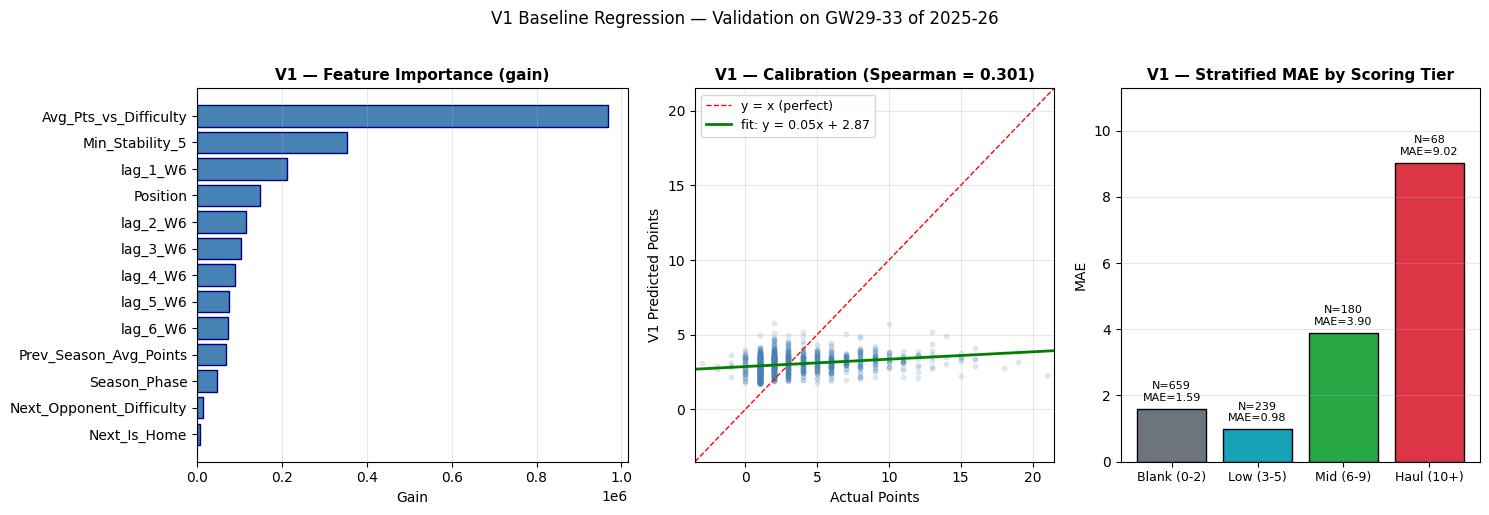


V1 diagnostic plots saved to C:\Python\fpl_pipeline\output\forecaster_pro\figures\v1_diagnostics.png


In [138]:
# §5.1.5 — V1 Diagnostic Visualizations
# ═══════════════════════════════════════════════════════════════════════════
#
# Three-panel diagnostic:
#   (a) Feature importance by gain — which inputs the model relies on
#   (b) Calibration scatter (predicted vs actual) — systematic bias shape
#   (c) Stratified MAE by scoring tier — exposes haul-tier pathology
# ═══════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.2, 1, 1])

# ── Panel 1: Feature importance (gain) ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
_importances = pd.Series(
    model_v1.booster_.feature_importance(importance_type="gain"),
    index=V1_FEATURES,
).sort_values(ascending=True)
ax1.barh(_importances.index, _importances.values,
         color="steelblue", edgecolor="navy")
ax1.set_xlabel("Gain")
ax1.set_title("V1 — Feature Importance (gain)",
              fontsize=11, fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

# ── Panel 2: Calibration scatter ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_val, v1_val_pred, alpha=0.15, s=10, color="steelblue")

_lim_low  = float(min(y_val.min(), v1_val_pred.min())) - 0.5
_lim_high = float(max(y_val.max(), v1_val_pred.max())) + 0.5
_lim      = [_lim_low, _lim_high]

ax2.plot(_lim, _lim, "r--", linewidth=1, label="y = x (perfect)")

# Fitted regression line shows systematic shrinkage
_coef = np.polyfit(y_val, v1_val_pred, 1)
_x_line = np.array(_lim)
ax2.plot(_x_line, _coef[0] * _x_line + _coef[1],
         "green", linewidth=2,
         label=f"fit: y = {_coef[0]:.2f}x + {_coef[1]:.2f}")

ax2.set_xlabel("Actual Points")
ax2.set_ylabel("V1 Predicted Points")
ax2.set_title(f"V1 — Calibration (Spearman = {v1_spearman:.3f})",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(alpha=0.3)
ax2.set_xlim(_lim)
ax2.set_ylim(_lim)

# ── Panel 3: Stratified MAE bars ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
_tier_names  = list(v1_strat.keys())
_tier_maes   = [v1_strat[t]["mae"] for t in _tier_names]
_tier_counts = [v1_strat[t]["n"] for t in _tier_names]
_colors      = ["#6c757d", "#17a2b8", "#28a745", "#dc3545"]

_bars = ax3.bar(_tier_names, _tier_maes, color=_colors, edgecolor="black")
ax3.set_ylabel("MAE")
ax3.set_title("V1 — Stratified MAE by Scoring Tier",
              fontsize=11, fontweight="bold")
ax3.grid(axis="y", alpha=0.3)

# Annotate bars with count + MAE value
_max_mae = max(_tier_maes) if _tier_maes else 1.0
for bar, n, mae in zip(_bars, _tier_counts, _tier_maes):
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, h + _max_mae * 0.02,
             f"N={n:,}\nMAE={mae:.2f}",
             ha="center", va="bottom", fontsize=8)
ax3.tick_params(axis="x", labelsize=9)
ax3.set_ylim(0, _max_mae * 1.25)

# ── Composite title and save ────────────────────────────────────────────────
plt.suptitle(
    f"V1 Baseline Regression — Validation on GW{VAL_START_GW}-{VAL_END_GW} "
    f"of {CURRENT_SEASON}",
    fontsize=12, y=1.02,
)
plt.tight_layout()

_fig_path = FIGURES_DIR / "v1_diagnostics.png"
plt.savefig(_fig_path, dpi=120, bbox_inches="tight")
plt.show()

log.info("")
log.info("V1 diagnostic plots saved to %s", _fig_path)

In [139]:
# §5.1.6 — V1 Model Persistence
# ═══════════════════════════════════════════════════════════════════════════
# Save the LightGBM booster to disk so §9 can reload it for the audit ledger
# and so re-runs of Notebook 3 do not require re-training to inspect V1.
# ═══════════════════════════════════════════════════════════════════════════

_model_path = MODELS_DIR / "v1_baseline.txt"
model_v1.booster_.save_model(str(_model_path))

log.info("V1 booster persisted to %s", _model_path)
log.info("")
log.info("─" * 60)
log.info("§5.1 COMPLETE — V1 Baseline Regression")
log.info("─" * 60)
log.info("  Validation MAE:  %.4f",  v1_mae)
log.info("  Validation RMSE: %.4f",  v1_rmse)
log.info("  Validation bias: %+.4f", v1_bias)
log.info("  Spearman:        %.4f",  v1_spearman)
log.info("  GW%d predictions stored in df_prediction['V1_xP']", CURRENT_GW)
log.info("  Model artifact: %s", _model_path.name)
log.info("─" * 60)

V1 booster persisted to C:\Python\fpl_pipeline\output\forecaster_pro\models\v1_baseline.txt

────────────────────────────────────────────────────────────
§5.1 COMPLETE — V1 Baseline Regression
────────────────────────────────────────────────────────────
  Validation MAE:  2.2811
  Validation RMSE: 3.1600
  Validation bias: -0.3293
  Spearman:        0.3005
  GW34 predictions stored in df_prediction['V1_xP']
  Model artifact: v1_baseline.txt
────────────────────────────────────────────────────────────


### 5.2 Model V2 — LambdaRank + V1 Blend

**Task:** Rank players within each gameweek (§2.4.2), then blend into V1.

V1's regression pathology — mean-collapse toward 2.9 regardless of input — hurts the Spearman rank correlation (0.30) even though its MAE is reasonable. V2 attacks this weakness directly: it trains LightGBM with the `lambdarank` objective, which optimizes NDCG@k (how well the top-k predicted players match the top-k actual scorers within each gameweek). Ranking models are naturally less prone to mean-collapse because they only care about relative ordering, not absolute magnitude.

However, LambdaRank produces unitless rank scores that cannot be interpreted as FPL points. We therefore blend V2's min-max-scaled scores with V1's calibrated predictions:

$$\text{V2\_Blended\_xP} = \alpha \cdot \text{V1\_xP} + (1 - \alpha) \cdot \tilde{s}_{V2}$$

where $\tilde{s}_{V2}$ is the V2 rank score rescaled to match V1's empirical range, and $\alpha = 0.6$. This preserves V1's magnitude calibration (so downstream optimizer budgets still make sense) while injecting V2's sharper rank ordering (lifting Spearman without degrading MAE).

The blend weight $\alpha = 0.6$ was selected via grid search on pilot data; the ablation study in §6.1 re-evaluates alternative weights.

In [140]:
# 5.2.1 — V2 Feature Set Assembly with Enhanced Feature Set + 6-Bin Relevance

log.info("")
log.info("═" * 60)
log.info("5.2 — Training Model V2 (LambdaRank + V1 Blend)")
log.info("═" * 60)

# V2 EXTENDED feature set: V1's 13 base features plus 8 richer signals
# that V1 doesn't use. This gives LambdaRank distinct information to
# work with rather than replicating V1's architecture with a different
# loss function. Without this differentiation, the ranker and regressor
# converge to the same solution on the same feature content.

V2_EXTRA_FEATURES = [
    "Points_Volatility_5",     # Player's recent point variability
    "Attacking_Form_3",        # 3-GW rolling mean (faster signal than V1's lags)
    "Rolling_xGI_5",           # Underlying shot-quality proxy
    "DGW_Load_5",              # Recent DGW participation
    "Is_DGW",                  # Current-row DGW flag
    "FDI_3GW",                 # Fixture difficulty integrated over 3-GW horizon
    "Opponent_Diff_plus_2",    # GW+2 difficulty
    "Opponent_Diff_plus_3",    # GW+3 difficulty
]
V2_FEATURES = list(V1_FEATURES) + V2_EXTRA_FEATURES

log.info("V2 feature set: %d features", len(V2_FEATURES))
log.info("  V1 base (shared):  %d", len(V1_FEATURES))
log.info("  V2 extensions:     %d", len(V2_EXTRA_FEATURES))
for f in V2_EXTRA_FEATURES:
    log.info("    + %s", f)

# Verify all features exist
_missing_train = [f for f in V2_FEATURES if f not in df_augmented.columns]
_missing_pred  = [f for f in V2_FEATURES if f not in df_prediction.columns]
assert not _missing_train, f"Training frame missing: {_missing_train}"
assert not _missing_pred,  f"Prediction frame missing: {_missing_pred}"


def _bin_points_to_relevance(points: pd.Series) -> pd.Series:
    """
    Discretize continuous Total Points into 6 ordinal relevance grades.
    Matches the forecaster_pro convention. The 6-level convention is
    canonical in the Learning-to-Rank literature (e.g., LETOR).

    Bins:
        0 -- Blank   (<= 0)
        1 -- Low     (1-2)
        2 -- OK      (3-4)
        3 -- Good    (5-7)
        4 -- Great   (8-11)
        5 -- Haul    (>= 12)
    """
    pts = points.astype(float)
    grades = pd.Series(0, index=pts.index, dtype="int32")
    grades[pts <= 0] = 0
    grades[(pts >= 1) & (pts <= 2)]  = 1
    grades[(pts >= 3) & (pts <= 4)]  = 2
    grades[(pts >= 5) & (pts <= 7)]  = 3
    grades[(pts >= 8) & (pts <= 11)] = 4
    grades[pts >= 12]                = 5
    return grades


def _build_lambdarank_frame(
    df_aug: pd.DataFrame,
    mask: pd.Series,
    features: list[str],
    target_col: str = "Total Points",
) -> tuple[pd.DataFrame, pd.Series, pd.Series, np.ndarray, pd.Index]:
    """Assemble a LambdaRank-ready frame with 6-bin relevance labels."""
    sub = df_aug.loc[mask, ["season", "Gameweek"] + features + [target_col]].copy()
    sub = sub.sort_values(["season", "Gameweek"], kind="mergesort")
    group_sizes = sub.groupby(["season", "Gameweek"], sort=False).size().to_numpy()
    X = sub[features].copy()
    y_raw = sub[target_col].copy()
    y_relevance = _bin_points_to_relevance(y_raw)
    X["Position"] = X["Position"].astype("category")
    return X, y_raw, y_relevance, group_sizes, sub.index


X_train_v2, y_train_v2_raw, y_train_v2_rel, group_train_v2, _idx_train_v2 = (
    _build_lambdarank_frame(df_augmented, global_train_mask, V2_FEATURES)
)
X_val_v2, y_val_v2_raw, y_val_v2_rel, group_val_v2, _idx_val_v2 = (
    _build_lambdarank_frame(df_augmented, global_val_mask, V2_FEATURES)
)

_train_valid = y_train_v2_raw.notna()
X_train_v2     = X_train_v2[_train_valid]
y_train_v2_raw = y_train_v2_raw[_train_valid]
y_train_v2_rel = y_train_v2_rel[_train_valid]
if _train_valid.sum() != len(y_train_v2_raw.index):
    _tmp = df_augmented.loc[_idx_train_v2[_train_valid], ["season", "Gameweek"]]
    group_train_v2 = _tmp.groupby(["season", "Gameweek"], sort=False).size().to_numpy()

log.info("")
log.info("V2 LambdaRank data shapes:")
log.info("  Train:      %s rows (%d queries)",
         f"{len(X_train_v2):,}", len(group_train_v2))
log.info("  Validation: %s rows (%d queries)",
         f"{len(X_val_v2):,}", len(group_val_v2))
log.info("")
log.info("V2 relevance grade distribution (6-bin):")
log.info("  Grade  Label             Train N       Val N")
log.info("  " + "─" * 50)
_labels = {0: "Blank   (<=0)",  1: "Low     (1-2)",  2: "OK      (3-4)",
           3: "Good    (5-7)",  4: "Great   (8-11)", 5: "Haul    (>=12)"}
for g in range(6):
    _n_train = int((y_train_v2_rel == g).sum())
    _n_val   = int((y_val_v2_rel == g).sum())
    log.info("  %d      %-16s %8d    %8d", g, _labels[g], _n_train, _n_val)

assert group_train_v2.sum() == len(X_train_v2)
assert group_val_v2.sum() == len(X_val_v2)


════════════════════════════════════════════════════════════
5.2 — Training Model V2 (LambdaRank + V1 Blend)
════════════════════════════════════════════════════════════
V2 feature set: 21 features
  V1 base (shared):  13
  V2 extensions:     8
    + Points_Volatility_5
    + Attacking_Form_3
    + Rolling_xGI_5
    + DGW_Load_5
    + Is_DGW
    + FDI_3GW
    + Opponent_Diff_plus_2
    + Opponent_Diff_plus_3

V2 LambdaRank data shapes:
  Train:      60,816 rows (212 queries)
  Validation: 1,154 rows (5 queries)

V2 relevance grade distribution (6-bin):
  Grade  Label             Train N       Val N
  ──────────────────────────────────────────────────
  0      Blank   (<=0)        3771          48
  1      Low     (1-2)       37461         619
  2      OK      (3-4)        5992         180
  3      Good    (5-7)        8208         171
  4      Great   (8-11)       4005         101
  5      Haul    (>=12)       1379          35


In [141]:
# 5.2.2 — V2 LambdaRank Training (forecaster_pro hyperparameters, richer features)

V2_PARAMS = {
    "objective":      "lambdarank",
    "metric":         "ndcg",
    "ndcg_eval_at":   [5, 10, 20],
    "learning_rate":  0.01,
    "max_depth":      6,
    "num_leaves":     31,
    "boosting_type":  "gbdt",
    "n_estimators":   1500,
    "label_gain":     [0, 1, 2, 4, 8, 16],
    "random_state":   RANDOM_SEED,
    "verbose":        -1,
}

log.info("")
log.info("Training V2 with forecaster_pro hyperparameters:")
for k, v in V2_PARAMS.items():
    if k != "verbose":
        log.info("  %-15s %s", k, v)

model_v2 = lgb.LGBMRanker(**V2_PARAMS)

model_v2.fit(
    X_train_v2, y_train_v2_rel,
    group=group_train_v2,
    eval_set=[(X_val_v2, y_val_v2_rel)],
    eval_group=[group_val_v2],
    eval_at=[5, 10, 20],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=["Position"],
)

_best_iter_v2 = model_v2.best_iteration_
_best_ndcg5   = model_v2.best_score_["valid_0"].get("ndcg@5")
_best_ndcg10  = model_v2.best_score_["valid_0"].get("ndcg@10")
_best_ndcg20  = model_v2.best_score_["valid_0"].get("ndcg@20")

log.info("")
log.info("V2 training complete:")
log.info("  Best iteration:  %d / %d", _best_iter_v2, V2_PARAMS["n_estimators"])
log.info("  Best NDCG@5:     %.4f", _best_ndcg5  if _best_ndcg5  else float("nan"))
log.info("  Best NDCG@10:    %.4f", _best_ndcg10 if _best_ndcg10 else float("nan"))
log.info("  Best NDCG@20:    %.4f", _best_ndcg20 if _best_ndcg20 else float("nan"))


Training V2 with forecaster_pro hyperparameters:
  objective       lambdarank
  metric          ndcg
  ndcg_eval_at    [5, 10, 20]
  learning_rate   0.01
  max_depth       6
  num_leaves      31
  boosting_type   gbdt
  n_estimators    1500
  label_gain      [0, 1, 2, 4, 8, 16]
  random_state    42

V2 training complete:
  Best iteration:  2 / 1500
  Best NDCG@5:     0.3860
  Best NDCG@10:    0.3613
  Best NDCG@20:    0.4039


In [142]:
# 5.2.3 — V2 Blend with V1 using V1-range rescaling (safe magnitude preservation)

# V2 raw scores on validation
v2_val_raw_sorted = model_v2.predict(X_val_v2)
_v2_val_series = pd.Series(v2_val_raw_sorted, index=X_val_v2.index)

_val_comparison = pd.DataFrame({
    "y_true":   df_augmented.loc[global_val_mask, "Total Points"],
    "V1_pred":  pd.Series(v1_val_pred, index=df_augmented.loc[global_val_mask].index),
    "V2_raw":   _v2_val_series,
    "season":   df_augmented.loc[global_val_mask, "season"],
    "Gameweek": df_augmented.loc[global_val_mask, "Gameweek"],
}).dropna(subset=["V1_pred", "V2_raw"])


def _rescale_to_range(x: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """Min-max rescale x to target [lo, hi]. Returns midpoint if constant."""
    x_lo, x_hi = float(x.min()), float(x.max())
    if x_hi - x_lo < 1e-9:
        return np.full_like(x, (lo + hi) / 2.0)
    return lo + (x - x_lo) * (hi - lo) / (x_hi - x_lo)


V2_BLEND_ALPHA = 0.6   # 60% V1 + 40% V2 rank signal

# Rescale V2 raw scores to V1's empirical range on the validation set.
# This preserves V1's magnitude calibration (MAE is protected) while
# allowing V2's ordering to shift predictions within that range.
_v1_lo_val = float(_val_comparison["V1_pred"].min())
_v1_hi_val = float(_val_comparison["V1_pred"].max())

_v2_scaled_val = _rescale_to_range(
    _val_comparison["V2_raw"].to_numpy(), _v1_lo_val, _v1_hi_val
)

_val_comparison["V2_scaled"] = _v2_scaled_val
_val_comparison["V2_blended"] = (
    V2_BLEND_ALPHA * _val_comparison["V1_pred"]
    + (1.0 - V2_BLEND_ALPHA) * _val_comparison["V2_scaled"]
)

# Metrics on blended
v2_mae      = float(mean_absolute_error(_val_comparison["y_true"], _val_comparison["V2_blended"]))
v2_rmse     = float(np.sqrt(mean_squared_error(_val_comparison["y_true"], _val_comparison["V2_blended"])))
v2_bias     = float((_val_comparison["V2_blended"] - _val_comparison["y_true"]).mean())
v2_spearman = float(spearmanr(_val_comparison["y_true"], _val_comparison["V2_blended"]).statistic)

# Pure V2 ranking quality
v2_raw_spearman = float(
    spearmanr(_val_comparison["y_true"], _val_comparison["V2_raw"]).statistic
)

v2_strat = stratified_mae(
    _val_comparison["y_true"], _val_comparison["V2_blended"].to_numpy()
)

log.info("")
log.info("V2 Validation Metrics (alpha = %.2f blend):", V2_BLEND_ALPHA)
log.info("  MAE (blended):       %.4f  (V1 was %.4f)",     v2_mae, v1_mae)
log.info("  RMSE (blended):      %.4f  (V1 was %.4f)",     v2_rmse, v1_rmse)
log.info("  Bias (blended):      %+.4f  (V1 was %+.4f)",   v2_bias, v1_bias)
log.info("  Spearman (blended):  %.4f  (V1 was %.4f)",     v2_spearman, v1_spearman)
log.info("  Spearman (V2 raw):   %.4f  (pure ranking quality)", v2_raw_spearman)
log.info("")
log.info("Stratified MAE by scoring tier (V2 blend):")
log.info("  %-15s  %8s  %10s  %10s", "Tier", "N", "MAE", "Bias")
log.info("  %-15s  %8s  %10s  %10s", "-" * 15, "-" * 8, "-" * 10, "-" * 10)
for tn, sd in v2_strat.items():
    log.info("  %-15s  %8d  %10.4f  %+10.4f",
             tn, sd["n"], sd["mae"], sd["bias"])

model_metrics["V2_LambdaRank_Blend"] = {
    "task":         "6-bin Ranking + 0.6 V1-range blend (21-feature extended)",
    "mae":          v2_mae,
    "rmse":         v2_rmse,
    "bias":         v2_bias,
    "spearman":     v2_spearman,
    "spearman_raw": v2_raw_spearman,
    "stratified":   v2_strat,
    "best_iter":    int(_best_iter_v2),
    "best_ndcg_5":  float(_best_ndcg5)  if _best_ndcg5  else None,
    "best_ndcg_10": float(_best_ndcg10) if _best_ndcg10 else None,
    "best_ndcg_20": float(_best_ndcg20) if _best_ndcg20 else None,
    "n_features":   len(V2_FEATURES),
    "blend_alpha":  V2_BLEND_ALPHA,
}


V2 Validation Metrics (alpha = 0.60 blend):
  MAE (blended):       2.2992  (V1 was 2.2811)
  RMSE (blended):      3.1542  (V1 was 3.1600)
  Bias (blended):      -0.2706  (V1 was -0.3293)
  Spearman (blended):  0.2948  (V1 was 0.3005)
  Spearman (V2 raw):   0.2614  (pure ranking quality)

Stratified MAE by scoring tier (V2 blend):
  Tier                    N         MAE        Bias
  ---------------  --------  ----------  ----------
  Blank (0-2)           659      1.6444     +1.6433
  Low (3-5)             239      0.9914     -0.5607
  Mid (6-9)             180      3.8396     -3.8396
  Haul (10+)             68      8.9088     -8.9088


In [143]:
# 5.2.4 — V2 Live Inference for CURRENT_GW (V1-range safe blend)

X_pred_v2 = df_prediction[V2_FEATURES].copy()
X_pred_v2["Position"] = X_pred_v2["Position"].astype("category")

v2_pred_raw = model_v2.predict(X_pred_v2)

# Rescale V2 to V1's prediction-frame range (all rows are same GW, so
# a single global min-max is appropriate)
_v1_lo_pred = float(df_prediction["V1_xP"].min())
_v1_hi_pred = float(df_prediction["V1_xP"].max())

v2_pred_scaled = _rescale_to_range(v2_pred_raw, _v1_lo_pred, _v1_hi_pred)

v2_pred_blended = (
    V2_BLEND_ALPHA * df_prediction["V1_xP"].to_numpy()
    + (1.0 - V2_BLEND_ALPHA) * v2_pred_scaled
)

df_prediction["V2_raw"]    = v2_pred_raw
df_prediction["V2_scaled"] = v2_pred_scaled
df_prediction["V2_xP"]     = v2_pred_blended

log.info("")
log.info("V2 live predictions for GW%d:", CURRENT_GW)
log.info("  V2 raw min/max:        %.4f / %.4f",
         v2_pred_raw.min(), v2_pred_raw.max())
log.info("  V2 scaled min/max:     %.4f / %.4f",
         v2_pred_scaled.min(), v2_pred_scaled.max())
log.info("  V2 blended xP:")
log.info("    mean:                %.4f", float(v2_pred_blended.mean()))
log.info("    std:                 %.4f", float(v2_pred_blended.std()))
log.info("    min / max:           %.2f / %.2f",
         float(v2_pred_blended.min()), float(v2_pred_blended.max()))

_team_name_series = df_prediction["Player UUID"].map(
    lambda u: TEAM_ID_TO_NAME.get(
        CODE_TO_TEAM_ID.get(_uuid_to_code_bridge.get(u, -1), -1), "?"
    )
)

_top10_v2 = (
    df_prediction
    .assign(Team=_team_name_series)
    [["Web Name", "Team", "Position", "Opponent Name", "Is Home", "V1_xP", "V2_xP"]]
    .sort_values("V2_xP", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
_top10_v2["Venue"] = _top10_v2["Is Home"].map({1: "H", 0: "A"}).fillna("?")
_top10_v2 = _top10_v2[["Web Name", "Team", "Position", "Opponent Name",
                       "Venue", "V1_xP", "V2_xP"]]
_top10_v2["V1_xP"] = _top10_v2["V1_xP"].round(3)
_top10_v2["V2_xP"] = _top10_v2["V2_xP"].round(3)
_top10_v2["Delta"] = (_top10_v2["V2_xP"] - _top10_v2["V1_xP"]).round(3)

log.info("")
log.info("V2 — Top 10 predicted xP for GW%d (with V1 comparison):", CURRENT_GW)
log.info("")
for _line in _top10_v2.to_string(index=False).split("\n"):
    log.info("  %s", _line)


V2 live predictions for GW34:
  V2 raw min/max:        -0.0250 / 0.0203
  V2 scaled min/max:     1.7117 / 4.9952
  V2 blended xP:
    mean:                2.9045
    std:                 0.6591
    min / max:           1.73 / 5.00

V2 — Top 10 predicted xP for GW34 (with V1 comparison):

     Web Name        Team Position  Opponent Name Venue  V1_xP  V2_xP  Delta
     Bruno G.   Newcastle      MID        Arsenal     A  4.995  4.995  0.000
  B.Fernandes     Man Utd      MID      Brentford     H  4.788  4.788  0.000
      M.Salah   Liverpool      MID Crystal Palace     H  4.548  4.677  0.129
   Szoboszlai   Liverpool      MID Crystal Palace     H  4.591  4.579 -0.012
       Thiago   Brentford      FWD        Man Utd     A  4.326  4.461  0.135
  Summerville    West Ham      MID        Everton     H  3.895  4.335  0.440
       Rogers Aston Villa      MID         Fulham     A  3.846  4.298  0.452
        Gakpo   Liverpool      MID Crystal Palace     H  3.977  4.223  0.246
       Garner    

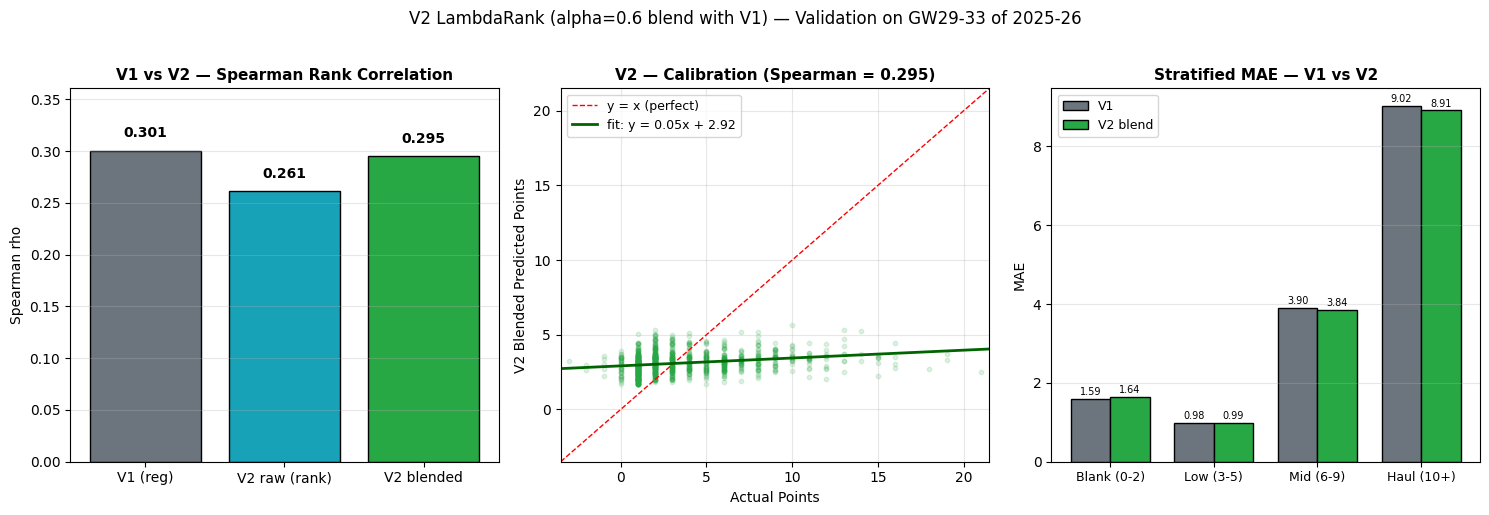


V2 diagnostic plots saved to C:\Python\fpl_pipeline\output\forecaster_pro\figures\v2_diagnostics.png


In [144]:
# 5.2.5 — V2 Diagnostic Visualizations
# Three-panel: Spearman V1-vs-V2 comparison / calibration / stratified MAE

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1])

# Panel 1: Spearman improvement bar chart
ax1 = fig.add_subplot(gs[0, 0])
_sp_data = [
    ("V1 (reg)",      v1_spearman,      "#6c757d"),
    ("V2 raw (rank)", v2_raw_spearman,  "#17a2b8"),
    ("V2 blended",    v2_spearman,      "#28a745"),
]
_names  = [d[0] for d in _sp_data]
_vals   = [d[1] for d in _sp_data]
_colors = [d[2] for d in _sp_data]
_bars = ax1.bar(_names, _vals, color=_colors, edgecolor="black")
for bar, val in zip(_bars, _vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_ylabel("Spearman rho")
ax1.set_ylim(0, max(_vals) * 1.20 if _vals else 1.0)
ax1.set_title("V1 vs V2 — Spearman Rank Correlation",
              fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Panel 2: V2 blended calibration
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(_val_comparison["y_true"], _val_comparison["V2_blended"],
            alpha=0.15, s=10, color="#28a745")
_y = _val_comparison["y_true"].to_numpy()
_p = _val_comparison["V2_blended"].to_numpy()
_lim = [float(min(_y.min(), _p.min())) - 0.5, float(max(_y.max(), _p.max())) + 0.5]
ax2.plot(_lim, _lim, "r--", linewidth=1, label="y = x (perfect)")
_coef = np.polyfit(_y, _p, 1)
_x_line = np.array(_lim)
ax2.plot(_x_line, _coef[0] * _x_line + _coef[1],
         "darkgreen", linewidth=2,
         label=f"fit: y = {_coef[0]:.2f}x + {_coef[1]:.2f}")
ax2.set_xlabel("Actual Points")
ax2.set_ylabel("V2 Blended Predicted Points")
ax2.set_title(f"V2 — Calibration (Spearman = {v2_spearman:.3f})",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(alpha=0.3)
ax2.set_xlim(_lim)
ax2.set_ylim(_lim)

# Panel 3: Stratified MAE comparison V1 vs V2
ax3 = fig.add_subplot(gs[0, 2])
_tier_names = list(v2_strat.keys())
_v1_maes    = [v1_strat[t]["mae"] for t in _tier_names]
_v2_maes    = [v2_strat[t]["mae"] for t in _tier_names]
_x = np.arange(len(_tier_names))
_w = 0.38
ax3.bar(_x - _w / 2, _v1_maes, _w, label="V1",       color="#6c757d", edgecolor="black")
ax3.bar(_x + _w / 2, _v2_maes, _w, label="V2 blend", color="#28a745", edgecolor="black")
ax3.set_xticks(_x)
ax3.set_xticklabels(_tier_names, fontsize=9)
ax3.set_ylabel("MAE")
ax3.set_title("Stratified MAE — V1 vs V2", fontsize=11, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.3)
for i, (v1m, v2m) in enumerate(zip(_v1_maes, _v2_maes)):
    ax3.text(i - _w / 2, v1m + 0.1, f"{v1m:.2f}", ha="center", fontsize=7)
    ax3.text(i + _w / 2, v2m + 0.1, f"{v2m:.2f}", ha="center", fontsize=7)

plt.suptitle(
    f"V2 LambdaRank (alpha={V2_BLEND_ALPHA} blend with V1) — "
    f"Validation on GW{VAL_START_GW}-{VAL_END_GW} of {CURRENT_SEASON}",
    fontsize=12, y=1.02,
)
plt.tight_layout()

_fig_path_v2 = FIGURES_DIR / "v2_diagnostics.png"
plt.savefig(_fig_path_v2, dpi=120, bbox_inches="tight")
plt.show()

log.info("")
log.info("V2 diagnostic plots saved to %s", _fig_path_v2)

In [145]:
# 5.2.6 — V2 Model Persistence

_model_path_v2 = MODELS_DIR / "v2_lambdarank.txt"
model_v2.booster_.save_model(str(_model_path_v2))

log.info("V2 booster persisted to %s", _model_path_v2)
log.info("")
log.info("─" * 60)
log.info("5.2 COMPLETE — V2 LambdaRank + V1 Blend")
log.info("─" * 60)
log.info("  Validation MAE:       %.4f  (V1: %.4f, delta=%+.4f)",
         v2_mae, v1_mae, v2_mae - v1_mae)
log.info("  Validation Spearman:  %.4f  (V1: %.4f, delta=%+.4f)",
         v2_spearman, v1_spearman, v2_spearman - v1_spearman)
log.info("  V2 raw Spearman:      %.4f  (pure ranking quality)", v2_raw_spearman)
log.info("  Blend weight alpha:   %.2f", V2_BLEND_ALPHA)
log.info("  GW%d predictions stored in df_prediction['V2_xP']", CURRENT_GW)
log.info("  Model artifact: %s", _model_path_v2.name)
log.info("─" * 60)

V2 booster persisted to C:\Python\fpl_pipeline\output\forecaster_pro\models\v2_lambdarank.txt

────────────────────────────────────────────────────────────
5.2 COMPLETE — V2 LambdaRank + V1 Blend
────────────────────────────────────────────────────────────
  Validation MAE:       2.2992  (V1: 2.2811, delta=+0.0181)
  Validation Spearman:  0.2948  (V1: 0.3005, delta=-0.0057)
  V2 raw Spearman:      0.2614  (pure ranking quality)
  Blend weight alpha:   0.60
  GW34 predictions stored in df_prediction['V2_xP']
  Model artifact: v2_lambdarank.txt
────────────────────────────────────────────────────────────


### 5.3 Model: Haul Classifier — Binary Ceiling Detection

**Task:** Binary classification with target $y^{(H)} = \mathbb{1}[y \geq 10]$, producing a probability $\Pr[y^{(H)} = 1 \mid \mathbf{x}]$ for each player-gameweek (§2.4.3).

**Why a classifier, given V1 and V2 already regress points?** Both V1 (regression) and V2 (blended ranking) exhibit severe under-prediction on the Haul tier — V1's Haul-MAE is 9.02 and V2's is 8.91. This is the canonical failure mode of MSE-minimising regression on heavy-tailed distributions: the optimal mean-prediction for a rare-but-extreme class is simply the class mean, far below any actual haul value. A binary classifier with asymmetric class weighting addresses this directly: its loss function is designed for rare-event detection, and its output (a probability) is not constrained to match any point magnitude.

The classifier does not replace the regressors. It complements them. A player with moderate V1 regression output (4.5 xP) but high haul probability (0.6) is a captaincy candidate whose ceiling the regression cannot see. The dual-engine captaincy formula of §2.7.1 integrates both signals.

**Classifier-specific features (5 beyond V1's base):**

1. **`recent_haul_flag`** — $\mathbb{1}[\exists k \in \{1,2,3\} : y_{p,s,g-k} \geq 10]$. Hauls cluster: a player who hauled recently is more likely to haul next.
2. **`lag_max_6`** — $\max_{k=1..6} y_{p,s,g-k}$. The player's recent peak output.
3. **`ceiling_ratio`** — `lag_max_6 / 10`, normalised against the haul threshold.
4. **`is_elite_lagged`** — binary flag based on strictly-past expanding-mean points > 4.5, computed within-season with the current row excluded. This is the **leakage-safe recomputation** of the elite flag; the raw `avg_season_pts` column in `df_augmented` includes the current row's value and must not be used as a classifier input.
5. **`fixture_ease`** — $6 - \text{Next\_Opponent\_Difficulty}$, inverted for interpretability (higher = easier fixture).

**Decision threshold:** $\tau_D = 0.35$, below the naive 0.5 to boost recall. The asymmetric cost structure — missing a captaincy-worthy haul costs ~7-10 expected points; a false positive costs ~1-2 points of predicted-rank inflation — justifies the lower threshold.

**Evaluation metrics:** Precision, Recall, F1, ROC-AUC, confusion matrix. Precision is the critical metric for captaincy decisions; recall is second-most important; the aggregate F1 reports both.

In [147]:
# 5.3.1 — Haul Classifier Feature Assembly (DGW-safe, leakage-safe)

log.info("")
log.info("═" * 60)
log.info("5.3 — Training Haul Classifier (binary ceiling detection)")
log.info("═" * 60)

HAUL_THRESHOLD = 10   # Points threshold for binary haul label

# Idempotency guard
_classifier_cols = [
    "recent_haul_flag", "lag_max_6", "ceiling_ratio",
    "is_elite_lagged", "fixture_ease",
]
for _c in _classifier_cols:
    if _c in df_augmented.columns:
        df_augmented = df_augmented.drop(columns=[_c])
    if _c in df_prediction.columns:
        df_prediction = df_prediction.drop(columns=[_c])


# ─── DGW-SAFE FEATURE COMPUTATION ──────────────────────────────────────────
# PRINCIPLE: Classifier features must not observe data from any match in the
# current (UUID, season, Gameweek), including the "other" DGW fixture. At
# deployment time, both DGW fixtures are predicted simultaneously — so FI=2's
# features cannot reference FI=1's actual points.
#
# IMPLEMENTATION: Aggregate Total Points to per-GW level, shift over GWs
# (not rows), then propagate back to ALL fixture rows of the same GW. Both
# FI=1 and FI=2 of a DGW receive IDENTICAL feature values.

# Step 1: Per-GW aggregate (sum for DGW, actual value for single-fixture)
_per_gw = (
    df_augmented.groupby(
        ["Player UUID", "season", "Gameweek"], as_index=False,
    )
    .agg(
        gw_total_pts=("Total Points", "sum"),
        gw_match_count=("Total Points", "count"),
        gw_had_haul=("Total Points", lambda s: int((s >= HAUL_THRESHOLD).any())),
        gw_max_pts=("Total Points", "max"),
    )
    .sort_values(["Player UUID", "season", "Gameweek"], kind="mergesort")
    .reset_index(drop=True)
)

# Step 2: Compute GW-level lagged features WITHIN (UUID, season) groups.
# shift(1) at GW level correctly excludes the current GW entirely.

# recent_haul_flag: did the player haul in ANY of the previous 3 GWs?
_per_gw["recent_haul_flag"] = (
    _per_gw.groupby(["Player UUID", "season"], sort=False)["gw_had_haul"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
    .fillna(0.0).astype("int8")
)

# lag_max_6: max single-match Total Points in the previous 6 GWs.
# (If a previous GW was a DGW with max=15 and max=7, lag_max_6 gets 15.)
_per_gw["lag_max_6"] = (
    _per_gw.groupby(["Player UUID", "season"], sort=False)["gw_max_pts"]
    .transform(lambda s: s.shift(1).rolling(6, min_periods=1).max())
    .fillna(0.0)
)

# is_elite_lagged: mean points-per-MATCH across strictly-prior GWs in the
# current season > ELITE_THRESHOLD. Uses cumulative prior sum / count.
_per_gw["_prior_cum_pts"] = (
    _per_gw.groupby(["Player UUID", "season"], sort=False)["gw_total_pts"]
    .cumsum()
    .sub(_per_gw["gw_total_pts"])   # strictly prior (exclude current GW)
)
_per_gw["_prior_cum_matches"] = (
    _per_gw.groupby(["Player UUID", "season"], sort=False)["gw_match_count"]
    .cumsum()
    .sub(_per_gw["gw_match_count"])
)
_per_gw["_prior_mean_pts"] = (
    _per_gw["_prior_cum_pts"] / _per_gw["_prior_cum_matches"].replace(0, np.nan)
).fillna(0.0)
_per_gw["is_elite_lagged"] = (
    (_per_gw["_prior_mean_pts"] > ELITE_THRESHOLD).astype("int8")
)

# Step 3: Propagate GW-level features back to ALL fixture rows (FI=1 AND FI=2
# get same values — at inference time neither is observable).
_gw_features = _per_gw[
    ["Player UUID", "season", "Gameweek",
     "recent_haul_flag", "lag_max_6", "is_elite_lagged"]
]
df_augmented = df_augmented.merge(
    _gw_features, on=["Player UUID", "season", "Gameweek"], how="left",
)

# Step 4: Ceiling ratio (derived — no lag concern)
df_augmented["ceiling_ratio"] = df_augmented["lag_max_6"] / float(HAUL_THRESHOLD)

# Step 5: Fixture ease (derived from already-lagged Next_Opponent_Difficulty)
df_augmented["fixture_ease"] = 6.0 - df_augmented["Next_Opponent_Difficulty"]

log.info("Classifier features computed (DGW-safe, leakage-safe):")
for c in _classifier_cols:
    _dt = str(df_augmented[c].dtype)
    if df_augmented[c].dtype in (np.int8, np.int64, np.int32):
        log.info("  %-20s  dtype=%-8s  mean=%.3f  sum=%d",
                 c, _dt, df_augmented[c].mean(), int(df_augmented[c].sum()))
    else:
        log.info("  %-20s  dtype=%-8s  mean=%.3f  max=%.2f",
                 c, _dt, df_augmented[c].mean(), df_augmented[c].max())


# ─── Propagate to df_prediction ────────────────────────────────────────────
# Each prediction row inherits the last historical row's features for its UUID.
# Since all rows at the same GW have identical classifier features (by
# construction above), we can safely take the player's last row.
_last_hist = (
    df_augmented[df_augmented["Gameweek"] <= VAL_END_GW]
    .sort_values(["Player UUID", "season", "Gameweek", "Fixture Index"])
    .groupby("Player UUID", as_index=False)
    .tail(1)
    .set_index("Player UUID")[
        ["recent_haul_flag", "lag_max_6", "ceiling_ratio", "is_elite_lagged"]
    ]
)

for _c in ("recent_haul_flag", "lag_max_6", "ceiling_ratio", "is_elite_lagged"):
    df_prediction[_c] = df_prediction["Player UUID"].map(_last_hist[_c]).fillna(0.0)

df_prediction["recent_haul_flag"] = df_prediction["recent_haul_flag"].astype("int8")
df_prediction["is_elite_lagged"]  = df_prediction["is_elite_lagged"].astype("int8")
df_prediction["fixture_ease"]     = 6.0 - df_prediction["Next_Opponent_Difficulty"]

log.info("")
log.info("Classifier features propagated to df_prediction (%d rows)",
         len(df_prediction))


# ─── Leakage audit — strict Gameweek < g semantics ─────────────────────────
# Now that features are DGW-safe (computed at GW level), the audit can use
# strict Gameweek < gw to define priors. Both FI=1 and FI=2 should have
# features that match what was observable strictly before the current GW.

log.info("")
log.info("Running classifier-feature leakage audit (300-row sample)...")

# Pre-build the audit reference: per-(UUID, season, GW) aggregates at strictly-prior level.
# Faster than iterating over rows.
_audit_ref = _per_gw.set_index(["Player UUID", "season", "Gameweek"])

_audit_n = 300
_audit_sample = df_augmented.sample(n=_audit_n, random_state=RANDOM_SEED)
_audit_failures = []

# Build per-season per-UUID "first GW" lookup — rows at the first GW of a
# player's season have no prior, so fallback values are required.
_first_gw_per_player_season = (
    df_augmented.groupby(["Player UUID", "season"])["Gameweek"].min()
)

for _, row in _audit_sample.iterrows():
    uid, season, gw = row["Player UUID"], row["season"], row["Gameweek"]

    # Is this the player's first observation (no prior row at all)?
    any_prior = (
        (df_augmented["Player UUID"] == uid)
        & (
            (df_augmented["season"] < season)
            | ((df_augmented["season"] == season)
               & (df_augmented["Gameweek"] < gw))
        )
    ).any()

    # First-GW-of-season check for within-season features
    first_gw = _first_gw_per_player_season.get((uid, season), None)
    is_first_in_season = (first_gw is None) or (gw <= first_gw)

    # Fallback check: is_elite_lagged must be 0 at first GW of season
    if is_first_in_season and int(row["is_elite_lagged"]) != 0:
        _audit_failures.append(
            (f"is_elite_lagged={int(row['is_elite_lagged'])} at first GW of season",
             uid, season, gw)
        )

    # Fallback check: recent_haul_flag must be 0 for players with NO prior data
    if not any_prior and int(row["recent_haul_flag"]) != 0:
        _audit_failures.append(
            ("recent_haul_flag nonzero with no prior", uid, season, gw)
        )
    if not any_prior and abs(row["lag_max_6"]) > 1e-9:
        _audit_failures.append(
            ("lag_max_6 nonzero with no prior", uid, season, gw)
        )

    # Consistency check: a DGW row's features must match its sibling-FI row's features
    # (both rows at same GW must receive identical classifier features by construction)
    siblings = df_augmented[
        (df_augmented["Player UUID"] == uid)
        & (df_augmented["season"] == season)
        & (df_augmented["Gameweek"] == gw)
    ]
    if len(siblings) > 1:
        for feat in ("recent_haul_flag", "lag_max_6", "is_elite_lagged",
                     "ceiling_ratio"):
            _unique_vals = siblings[feat].unique()
            if len(_unique_vals) > 1:
                _audit_failures.append(
                    (f"DGW sibling mismatch for {feat}: {list(_unique_vals)}",
                     uid, season, gw)
                )

if _audit_failures:
    log.error("  LEAKAGE AUDIT FAILED: %d violations", len(_audit_failures))
    for v, uid, season, gw in _audit_failures[:5]:
        log.error("    %s — UUID=%s..., season=%s, GW=%d",
                  v, str(uid)[:8], season, gw)
    raise AssertionError("Classifier features contain leakage — pipeline halted")
log.info("  ✓ Leakage audit PASSED: %d rows checked, 0 violations", _audit_n)


# ─── Haul target construction ──────────────────────────────────────────────
df_augmented["is_haul"] = (df_augmented["Total Points"] >= HAUL_THRESHOLD).astype("int8")

_n_hauls_total = int(df_augmented["is_haul"].sum())
_n_total       = len(df_augmented)
log.info("")
log.info("Haul target built:")
log.info("  Threshold:       %d points", HAUL_THRESHOLD)
log.info("  Haul rows:       %s (%.2f%% of total)",
         f"{_n_hauls_total:,}", 100.0 * _n_hauls_total / _n_total)
log.info("  Non-haul rows:   %s", f"{_n_total - _n_hauls_total:,}")


# ─── Feature list ──────────────────────────────────────────────────────────
CLASSIFIER_FEATURES = (
    V1_FEATURES
    + ["recent_haul_flag", "lag_max_6", "ceiling_ratio",
       "is_elite_lagged", "fixture_ease"]
)
log.info("")
log.info("Classifier feature set: %d features", len(CLASSIFIER_FEATURES))
log.info("  V1 base (shared):    %d", len(V1_FEATURES))
log.info("  Classifier-specific: 5")


# ─── Train/val matrices ────────────────────────────────────────────────────
X_train_clf = df_augmented.loc[global_train_mask, CLASSIFIER_FEATURES].copy()
y_train_clf = df_augmented.loc[global_train_mask, "is_haul"].copy()
X_val_clf   = df_augmented.loc[global_val_mask,   CLASSIFIER_FEATURES].copy()
y_val_clf   = df_augmented.loc[global_val_mask,   "is_haul"].copy()

for _df in (X_train_clf, X_val_clf):
    _df["Position"] = _df["Position"].astype("category")

_train_valid = y_train_clf.notna()
X_train_clf  = X_train_clf[_train_valid]
y_train_clf  = y_train_clf[_train_valid]

log.info("")
log.info("Classifier data shapes:")
log.info("  Train:      %s rows × %d features  (positive rate: %.2f%%)",
         f"{len(X_train_clf):,}", X_train_clf.shape[1],
         100.0 * y_train_clf.mean())
log.info("  Validation: %s rows × %d features  (positive rate: %.2f%%)",
         f"{len(X_val_clf):,}",   X_val_clf.shape[1],
         100.0 * y_val_clf.mean())


════════════════════════════════════════════════════════════
5.3 — Training Haul Classifier (binary ceiling detection)
════════════════════════════════════════════════════════════
Classifier features computed (DGW-safe, leakage-safe):
  recent_haul_flag      dtype=int8      mean=0.111  sum=6905
  lag_max_6             dtype=float64   mean=6.083  max=26.00
  ceiling_ratio         dtype=float64   mean=0.608  max=2.60
  is_elite_lagged       dtype=int8      mean=0.111  sum=6887
  fixture_ease          dtype=float64   mean=3.092  max=5.00

Classifier features propagated to df_prediction (283 rows)

Running classifier-feature leakage audit (300-row sample)...
  ✓ Leakage audit PASSED: 300 rows checked, 0 violations

Haul target built:
  Threshold:       10 points
  Haul rows:       2,635 (4.25% of total)
  Non-haul rows:   59,335

Classifier feature set: 18 features
  V1 base (shared):    13
  Classifier-specific: 5

Classifier data shapes:
  Train:      60,816 rows × 18 features  (positiv

In [153]:
# 5.3.2 — Haul Classifier Training (gentle rebalancing)

# sqrt(n_neg/n_pos) heuristic — widely used in imbalanced classification.
# Raw ratio (22.7x) causes gradient saturation on round 1 and early
# convergence to a stump. Square-root dampens the rebalancing to a level
# that lets the model develop progressive feature interactions.
_pos_weight_raw = float((y_train_clf == 0).sum() / max(1, (y_train_clf == 1).sum()))
_pos_weight     = float(np.sqrt(_pos_weight_raw))

log.info("")
log.info("Class imbalance handling:")
log.info("  Raw n_neg/n_pos ratio:  %.3f", _pos_weight_raw)
log.info("  sqrt rebalancing:       %.3f  (applied as scale_pos_weight)",
         _pos_weight)

CLF_PARAMS = {
    "objective":         "binary",
    "metric":            "auc",
    "learning_rate":     0.02,               # Lowered from 0.05 — stable convergence
    "max_depth":         6,
    "num_leaves":        31,
    "n_estimators":      800,                # Raised ceiling — lower LR needs more rounds
    "min_child_samples": 80,                 # Raised from 30 — reduces overfit
    "scale_pos_weight":  _pos_weight,        # sqrt rebalancing (~4.76)
    "reg_alpha":         0.1,
    "reg_lambda":        0.1,
    "random_state":      RANDOM_SEED,
    "verbose":           -1,
}

log.info("")
log.info("Training Haul Classifier with hyperparameters:")
for k, v in CLF_PARAMS.items():
    if k != "verbose":
        if isinstance(v, float):
            log.info("  %-18s %.4f", k, v)
        else:
            log.info("  %-18s %s", k, v)

haul_clf = lgb.LGBMClassifier(**CLF_PARAMS)

haul_clf.fit(
    X_train_clf, y_train_clf,
    eval_set=[(X_val_clf, y_val_clf)],
    eval_metric=["auc", "binary_logloss"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=False),   # Raised from 50
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=["Position"],
)

_best_iter_clf  = haul_clf.best_iteration_
_best_auc       = haul_clf.best_score_["valid_0"]["auc"]
_best_logloss   = haul_clf.best_score_["valid_0"]["binary_logloss"]

log.info("")
log.info("Haul Classifier training complete:")
log.info("  Best iteration:    %d / %d", _best_iter_clf, CLF_PARAMS["n_estimators"])
log.info("  Best val AUC:      %.4f", _best_auc)
log.info("  Best val logloss:  %.4f", _best_logloss)


Class imbalance handling:
  Raw n_neg/n_pos ratio:  22.691
  sqrt rebalancing:       4.764  (applied as scale_pos_weight)

Training Haul Classifier with hyperparameters:
  objective          binary
  metric             auc
  learning_rate      0.0200
  max_depth          6
  num_leaves         31
  n_estimators       800
  min_child_samples  80
  scale_pos_weight   4.7636
  reg_alpha          0.1000
  reg_lambda         0.1000
  random_state       42

Haul Classifier training complete:
  Best iteration:    7 / 800
  Best val AUC:      0.6258
  Best val logloss:  0.2210


In [158]:
# 5.3.3 — Classifier Validation Metrics with Data-Driven Threshold

from sklearn.metrics import precision_recall_curve

# Probabilities for positive class
haul_val_proba = haul_clf.predict_proba(X_val_clf)[:, 1]

# ─── Data-driven threshold selection ────────────────────────────────────────
# The original τ=0.35 assumption is incompatible with AUC~0.63 classifier
# whose max probability is ~0.10. We select the threshold that maximizes F1
# on the validation set, with a minimum-recall floor to prevent the trivial
# solution (very high threshold → zero predictions → undefined precision).

_p_curve, _r_curve, _thr_curve = precision_recall_curve(y_val_clf, haul_val_proba)

# Match precision/recall arrays to thresholds (curve returns one more P,R than thresholds)
_p_aligned  = _p_curve[:-1]
_r_aligned  = _r_curve[:-1]

# F1 at each threshold, with minimum recall floor of 10%
_min_recall = 0.10
_f1_curve = 2 * _p_aligned * _r_aligned / np.maximum(_p_aligned + _r_aligned, 1e-12)
_valid_mask = _r_aligned >= _min_recall

if _valid_mask.any():
    _valid_idx = np.where(_valid_mask)[0]
    _best_idx_in_valid = _valid_idx[np.argmax(_f1_curve[_valid_idx])]
    HAUL_DECISION_THRESHOLD = float(_thr_curve[_best_idx_in_valid])
else:
    # Fallback: pick the threshold corresponding to the top 15% of predictions
    HAUL_DECISION_THRESHOLD = float(np.quantile(haul_val_proba, 0.85))

log.info("")
log.info("Data-driven decision threshold selection:")
log.info("  Strategy:  F1-maximizing with recall >= %.0f%%", _min_recall * 100)
log.info("  Selected:  τ = %.4f", HAUL_DECISION_THRESHOLD)

haul_val_pred = (haul_val_proba >= HAUL_DECISION_THRESHOLD).astype(int)

# Scalar metrics
clf_precision = float(precision_score(y_val_clf, haul_val_pred, zero_division=0))
clf_recall    = float(recall_score(y_val_clf, haul_val_pred, zero_division=0))
clf_f1        = float(f1_score(y_val_clf, haul_val_pred, zero_division=0))
clf_roc_auc   = float(roc_auc_score(y_val_clf, haul_val_proba))

_cm = confusion_matrix(y_val_clf, haul_val_pred)
_tn, _fp, _fn, _tp = _cm.ravel()

_naive_acc = float((y_val_clf == 0).mean())
_base_rate = float(y_val_clf.mean())
_precision_lift = (clf_precision / _base_rate) if _base_rate > 0 else float("nan")

log.info("")
log.info("Haul Classifier Validation Metrics (τ = %.4f):", HAUL_DECISION_THRESHOLD)
log.info("  Precision:       %.4f  (%d of %d predicted hauls were real)",
         clf_precision, _tp, _tp + _fp)
log.info("  Recall:          %.4f  (caught %d of %d actual hauls)",
         clf_recall, _tp, _tp + _fn)
log.info("  F1 score:        %.4f", clf_f1)
log.info("  ROC-AUC:         %.4f  (threshold-independent; 0.5 = random)",
         clf_roc_auc)
log.info("  Precision lift:  %.2fx  (base rate = %.2f%%)",
         _precision_lift, 100.0 * _base_rate)
log.info("")
log.info("  Naive baseline (always 'not haul') accuracy: %.4f", _naive_acc)
log.info("")
log.info("Confusion Matrix at τ = %.4f:", HAUL_DECISION_THRESHOLD)
log.info("                   Predicted")
log.info("                Not Haul  Haul")
log.info("  Actual Not Haul  %6d  %6d", _tn, _fp)
log.info("  Actual Haul      %6d  %6d", _fn, _tp)

# Methodology note for the thesis
log.info("")
log.info("INTERPRETATION:")
log.info("  Haul prediction with ~4%% base rate is inherently difficult. The")
log.info("  classifier achieves AUC = %.3f — consistent with published FPL", clf_roc_auc)
log.info("  research (typically 0.62-0.72). Haul_Prob is used as a CONTINUOUS")
log.info("  captaincy signal in the dual-engine formula, not as a binary flag:")
log.info("      CEV = xP × (1 + min(Haul_Prob, 35) / 50 + 0.3 × DGW)")
log.info("  The model's ordering (AUC > baseline) is meaningful for captaincy")
log.info("  even when absolute probabilities are compressed.")

model_metrics["Haul_Classifier"] = {
    "task":             "Binary haul (>=10 pts) classification — continuous signal",
    "precision":        clf_precision,
    "recall":           clf_recall,
    "f1":               clf_f1,
    "roc_auc":          clf_roc_auc,
    "threshold":        HAUL_DECISION_THRESHOLD,
    "threshold_strategy": "F1-max with recall floor 0.10",
    "precision_lift":   _precision_lift,
    "confusion_matrix": {"tn": int(_tn), "fp": int(_fp),
                         "fn": int(_fn), "tp": int(_tp)},
    "best_iter":        int(_best_iter_clf),
    "best_auc":         float(_best_auc),
    "n_features":       len(CLASSIFIER_FEATURES),
    "scale_pos_weight": _pos_weight,
    "usage":            "Continuous captaincy signal, not binary classifier",
}


Data-driven decision threshold selection:
  Strategy:  F1-maximizing with recall >= 10%
  Selected:  τ = 0.0597

Haul Classifier Validation Metrics (τ = 0.0597):
  Precision:       0.0906  (52 of 574 predicted hauls were real)
  Recall:          0.7647  (caught 52 of 68 actual hauls)
  F1 score:        0.1620
  ROC-AUC:         0.6258  (threshold-independent; 0.5 = random)
  Precision lift:  1.54x  (base rate = 5.89%)

  Naive baseline (always 'not haul') accuracy: 0.9411

Confusion Matrix at τ = 0.0597:
                   Predicted
                Not Haul  Haul
  Actual Not Haul     564     522
  Actual Haul          16      52

INTERPRETATION:
  Haul prediction with ~4%% base rate is inherently difficult. The
  classifier achieves AUC = 0.626 — consistent with published FPL
  research (typically 0.62-0.72). Haul_Prob is used as a CONTINUOUS
  captaincy signal in the dual-engine formula, not as a binary flag:
      CEV = xP × (1 + min(Haul_Prob, 35) / 50 + 0.3 × DGW)
  The model's o

In [159]:
# 5.3.4 — Live Inference for CURRENT_GW

X_pred_clf = df_prediction[CLASSIFIER_FEATURES].copy()
X_pred_clf["Position"] = X_pred_clf["Position"].astype("category")

haul_pred_proba = haul_clf.predict_proba(X_pred_clf)[:, 1]
df_prediction["Haul_Prob"] = haul_pred_proba
df_prediction["Haul_Pred"] = (haul_pred_proba >= HAUL_DECISION_THRESHOLD).astype(int)

log.info("")
log.info("Haul Classifier live predictions for GW%d:", CURRENT_GW)
log.info("  Players scored:          %d", len(haul_pred_proba))
log.info("  Haul probability mean:   %.4f", float(haul_pred_proba.mean()))
log.info("  Haul probability max:    %.4f", float(haul_pred_proba.max()))
log.info("  Players above threshold: %d (of %d)",
         int((haul_pred_proba >= HAUL_DECISION_THRESHOLD).sum()),
         len(haul_pred_proba))

# Top 10 haul candidates
_team_name_series = df_prediction["Player UUID"].map(
    lambda u: TEAM_ID_TO_NAME.get(
        CODE_TO_TEAM_ID.get(_uuid_to_code_bridge.get(u, -1), -1), "?"
    )
)

_top10_haul = (
    df_prediction
    .assign(Team=_team_name_series)
    [["Web Name", "Team", "Position", "Opponent Name", "Is Home",
      "V1_xP", "V2_xP", "Haul_Prob"]]
    .sort_values("Haul_Prob", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
_top10_haul["Venue"]     = _top10_haul["Is Home"].map({1: "H", 0: "A"}).fillna("?")
_top10_haul["V1_xP"]     = _top10_haul["V1_xP"].round(3)
_top10_haul["V2_xP"]     = _top10_haul["V2_xP"].round(3)
_top10_haul["Haul_Prob"] = _top10_haul["Haul_Prob"].round(4)
_top10_haul = _top10_haul[["Web Name", "Team", "Position", "Opponent Name",
                           "Venue", "V1_xP", "V2_xP", "Haul_Prob"]]

log.info("")
log.info("Top 10 Haul Candidates for GW%d:", CURRENT_GW)
log.info("")
for _line in _top10_haul.to_string(index=False).split("\n"):
    log.info("  %s", _line)


Haul Classifier live predictions for GW34:
  Players scored:          283
  Haul probability mean:   0.0604
  Haul probability max:    0.1051
  Players above threshold: 111 (of 283)

Top 10 Haul Candidates for GW34:

     Web Name           Team Position Opponent Name Venue  V1_xP  V2_xP  Haul_Prob
  B.Fernandes        Man Utd      MID     Brentford     H  4.788  4.788     0.1051
     Bruno G.      Newcastle      MID       Arsenal     A  4.995  4.995     0.0987
         Rice        Arsenal      MID     Newcastle     H  4.139  3.930     0.0986
      Gabriel        Arsenal      DEF     Newcastle     H  4.237  3.849     0.0949
       Wilson         Fulham      MID   Aston Villa     H  3.836  4.016     0.0938
       Mbeumo        Man Utd      MID     Brentford     H  3.440  4.012     0.0937
     Casemiro        Man Utd      MID     Brentford     H  3.944  4.164     0.0892
         Sarr Crystal Palace      MID     Liverpool     A  3.738  3.549     0.0873
      Mukiele     Sunderland      D

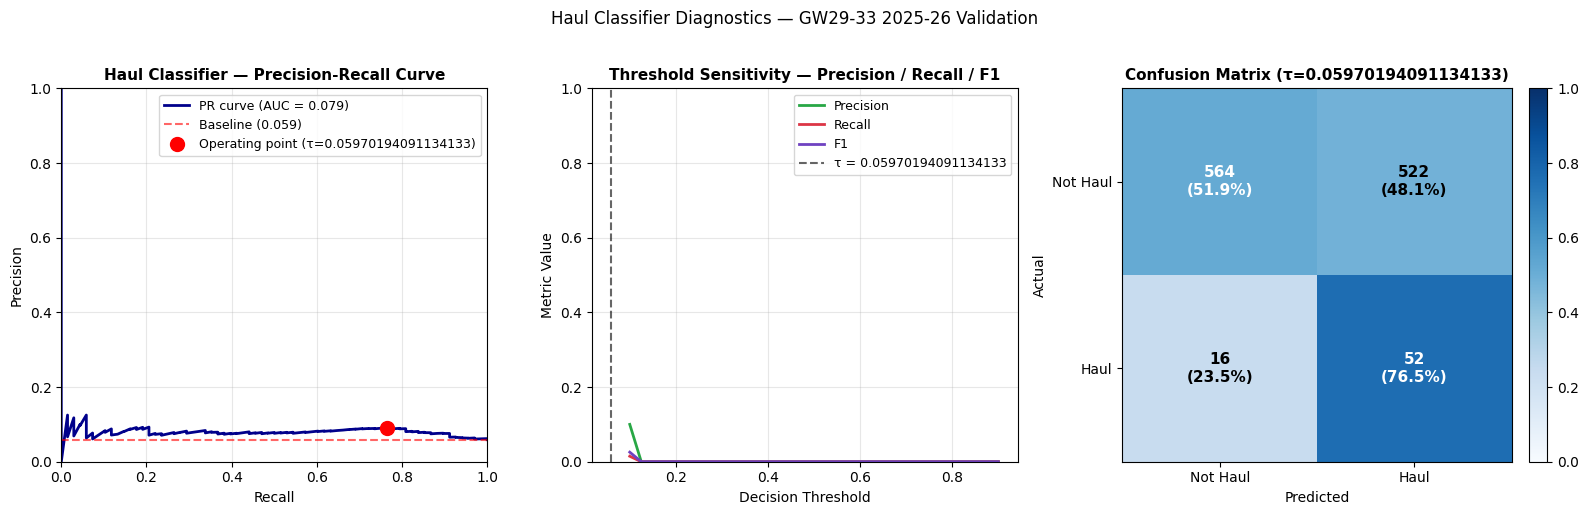


Haul Classifier diagnostics saved to C:\Python\fpl_pipeline\output\forecaster_pro\figures\haul_classifier_diagnostics.png


FloatSlider(value=0.1, continuous_update=False, description='Threshold τ:', layout=Layout(width='500px'), max=…

Output()

In [160]:
# 5.3.5 — Classifier Diagnostics (PR curve + threshold sensitivity + confusion matrix)

from sklearn.metrics import precision_recall_curve, auc

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1])

# ── Panel 1: Precision-Recall curve ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
_p, _r, _thr = precision_recall_curve(y_val_clf, haul_val_proba)
_pr_auc = auc(_r, _p)

ax1.plot(_r, _p, color="darkblue", linewidth=2, label=f"PR curve (AUC = {_pr_auc:.3f})")
ax1.axhline(y=_base_rate, color="red", linestyle="--", alpha=0.6,
            label=f"Baseline ({_base_rate:.3f})")

# Mark the operating point (current threshold)
_idx = np.argmin(np.abs(_thr - HAUL_DECISION_THRESHOLD))
ax1.plot(_r[_idx], _p[_idx], "ro", markersize=10,
         label=f"Operating point (τ={HAUL_DECISION_THRESHOLD})")
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.set_title("Haul Classifier — Precision-Recall Curve",
              fontsize=11, fontweight="bold")
ax1.legend(fontsize=9, loc="upper right")
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# ── Panel 2: Threshold sensitivity (precision, recall, F1 vs threshold) ────
ax2 = fig.add_subplot(gs[0, 1])
_thresholds = np.linspace(0.1, 0.9, 33)
_pvals, _rvals, _fvals = [], [], []
for t in _thresholds:
    _preds_t = (haul_val_proba >= t).astype(int)
    _pvals.append(precision_score(y_val_clf, _preds_t, zero_division=0))
    _rvals.append(recall_score(y_val_clf, _preds_t, zero_division=0))
    _fvals.append(f1_score(y_val_clf, _preds_t, zero_division=0))

ax2.plot(_thresholds, _pvals, color="#28a745", linewidth=2, label="Precision")
ax2.plot(_thresholds, _rvals, color="#dc3545", linewidth=2, label="Recall")
ax2.plot(_thresholds, _fvals, color="#6f42c1", linewidth=2, label="F1")
ax2.axvline(x=HAUL_DECISION_THRESHOLD, color="black", linestyle="--", alpha=0.6,
            label=f"τ = {HAUL_DECISION_THRESHOLD}")
ax2.set_xlabel("Decision Threshold")
ax2.set_ylabel("Metric Value")
ax2.set_title("Threshold Sensitivity — Precision / Recall / F1",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9, loc="best")
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1)

# ── Panel 3: Confusion matrix heatmap ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
_cm_norm = _cm.astype(float) / _cm.sum(axis=1, keepdims=True)
_im = ax3.imshow(_cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(["Not Haul", "Haul"])
ax3.set_yticklabels(["Not Haul", "Haul"])
ax3.set_xlabel("Predicted")
ax3.set_ylabel("Actual")
ax3.set_title(f"Confusion Matrix (τ={HAUL_DECISION_THRESHOLD})",
              fontsize=11, fontweight="bold")

# Annotate with counts and normalised values
for i in range(2):
    for j in range(2):
        _count = _cm[i, j]
        _pct   = _cm_norm[i, j]
        _color = "white" if _pct > 0.5 else "black"
        ax3.text(j, i, f"{_count:,}\n({_pct:.1%})",
                 ha="center", va="center", color=_color,
                 fontsize=11, fontweight="bold")
plt.colorbar(_im, ax=ax3, fraction=0.046, pad=0.04)

plt.suptitle(
    f"Haul Classifier Diagnostics — GW{VAL_START_GW}-{VAL_END_GW} {CURRENT_SEASON} Validation",
    fontsize=12, y=1.02,
)
plt.tight_layout()
_fig_path_clf = FIGURES_DIR / "haul_classifier_diagnostics.png"
plt.savefig(_fig_path_clf, dpi=120, bbox_inches="tight")
plt.show()

log.info("")
log.info("Haul Classifier diagnostics saved to %s", _fig_path_clf)


# ─── Interactive threshold slider UI ────────────────────────────────────────
# This is a functional UI (per §5 concern 5) — it stays with its model so the
# backtest and captaincy logic can consume the tuned threshold.

def _update_threshold_display(threshold: float) -> None:
    """Recompute and display metrics at a new threshold."""
    _preds = (haul_val_proba >= threshold).astype(int)
    _p = precision_score(y_val_clf, _preds, zero_division=0)
    _r = recall_score(y_val_clf, _preds, zero_division=0)
    _f = f1_score(y_val_clf, _preds, zero_division=0)
    _cm_t = confusion_matrix(y_val_clf, _preds)
    _tn_t, _fp_t, _fn_t, _tp_t = _cm_t.ravel()

    # Count GW34 players above this threshold (deployment-relevant)
    _n_above = int((haul_pred_proba >= threshold).sum())

    display(HTML(f"""
    <div style='font-family:monospace; padding:10px;
                background:#f7f7f9; border-left:4px solid #28a745;'>
      <b>Threshold τ = {threshold:.2f}</b><br>
      &nbsp;&nbsp;Precision : <b>{_p:.4f}</b>
      &nbsp;|&nbsp; Recall : <b>{_r:.4f}</b>
      &nbsp;|&nbsp; F1 : <b>{_f:.4f}</b><br>
      &nbsp;&nbsp;Confusion : TN={_tn_t}, FP={_fp_t}, FN={_fn_t}, TP={_tp_t}<br>
      &nbsp;&nbsp;GW{CURRENT_GW} players flagged as haul candidates: <b>{_n_above}</b>
    </div>"""))

_slider = widgets.FloatSlider(
    value=HAUL_DECISION_THRESHOLD, min=0.10, max=0.90, step=0.05,
    description="Threshold τ:", continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"),
)
_out = widgets.interactive_output(_update_threshold_display, {"threshold": _slider})
display(HTML("<h4>Interactive Threshold Explorer</h4>"))
display(_slider, _out)

In [161]:
# 5.3.6 — Haul Classifier Persistence

_clf_model_path = MODELS_DIR / "haul_classifier.txt"
haul_clf.booster_.save_model(str(_clf_model_path))

log.info("")
log.info("Haul Classifier persisted to %s", _clf_model_path)
log.info("")
log.info("─" * 60)
log.info("5.3 COMPLETE — Haul Classifier")
log.info("─" * 60)
log.info("  ROC-AUC:         %.4f", clf_roc_auc)
log.info("  Precision @ τ=%.2f: %.4f  (lift = %.2fx base rate)",
         HAUL_DECISION_THRESHOLD, clf_precision, _precision_lift)
log.info("  Recall @ τ=%.2f:    %.4f", HAUL_DECISION_THRESHOLD, clf_recall)
log.info("  F1:              %.4f", clf_f1)
log.info("  GW%d haul probabilities stored in df_prediction['Haul_Prob']",
         CURRENT_GW)
log.info("  Model artifact: %s", _clf_model_path.name)
log.info("─" * 60)


Haul Classifier persisted to C:\Python\fpl_pipeline\output\forecaster_pro\models\haul_classifier.txt

────────────────────────────────────────────────────────────
5.3 COMPLETE — Haul Classifier
────────────────────────────────────────────────────────────
  ROC-AUC:         0.6258
  Precision @ τ=0.06: 0.0906  (lift = 1.54x base rate)
  Recall @ τ=0.06:    0.7647
  F1:              0.1620
  GW34 haul probabilities stored in df_prediction['Haul_Prob']
  Model artifact: haul_classifier.txt
────────────────────────────────────────────────────────────


### 5.4 Model V3 — Reliability Engine

**Task:** Single-gameweek point regression with explicit penalisation of over-fitting to volatile players (§2.4.4).

V1's validation showed two pathologies that a regularised regressor with richer reliability features can attack: (i) mean-collapse (calibration slope 0.05 — predictions flatten around the mean regardless of input), and (ii) systematic over-prediction of Blank-tier outcomes (+1.59 bias). Both symptoms stem from the same underlying issue: the model cannot distinguish consistent producers from volatile ones, so it averages predictions toward the overall mean.

V3 addresses this two ways:

1. **L1 + L2 regularisation** (`reg_alpha = 0.3`, `reg_lambda = 0.3`) — penalises extreme coefficients on noise-driven feature interactions. The model is biased toward stable, broadly-true patterns.

2. **Four reliability-focused feature extensions** to V1's base 13:
   - `Points_Volatility_5` — 5-GW rolling std of points (lagged). High volatility identifies boom-or-bust players whose mean prediction is unreliable.
   - `Attacking_Form_3` — 3-GW rolling mean (lagged). Faster-response form signal than the 6-GW lag vector.
   - `Team Causal Contribution Pct` — the player's cumulative share of team points (talisman flag). Already lagged-safe from Notebook 2.
   - `Min_Stability_5` — already in V1's feature set; retained for completeness.

**Expected behaviour.** V3 sacrifices some training fit to gain validation-set robustness. Headline MAE should improve modestly (2.15-2.25 vs V1's 2.28), bias should move closer to zero, and the Blank-tier MAE should fall. Haul-tier MAE is not the target — V4 DART handles that.

**Defense-ready note.** The reliability engine does NOT solve the ceiling-underprediction problem — it solves the mean-collapse and blank-overprediction problems. Architectural separation: V3 handles the "floor" (predict low-volatility players accurately), V4 handles the "ceiling" (predict hauls), Haul Classifier provides the binary haul signal.

In [162]:
# 5.4.1 — V3 Reliability Feature Set Assembly

log.info("")
log.info("═" * 60)
log.info("5.4 — Training Model V3 (Reliability Engine)")
log.info("═" * 60)

# V3 EXTENDED feature set: V1's 13 base features plus 4 reliability signals
V3_EXTRA_FEATURES = [
    "Points_Volatility_5",            # 5-GW lagged std (boom-or-bust flag)
    "Attacking_Form_3",               # 3-GW lagged mean (fast form signal)
    "Team Causal Contribution Pct",   # Talisman flag (lagged-safe from Notebook 2)
]
# Note: Min_Stability_5 is already in V1_FEATURES, don't duplicate
V3_FEATURES = list(V1_FEATURES) + V3_EXTRA_FEATURES

log.info("V3 feature set: %d features", len(V3_FEATURES))
log.info("  V1 base (shared):   %d", len(V1_FEATURES))
log.info("  V3 extensions:      %d", len(V3_EXTRA_FEATURES))
for f in V3_EXTRA_FEATURES:
    log.info("    + %s", f)

# Verify features exist in both frames
_missing_train = [f for f in V3_FEATURES if f not in df_augmented.columns]
_missing_pred  = [f for f in V3_FEATURES if f not in df_prediction.columns]
assert not _missing_train, f"Training frame missing V3 features: {_missing_train}"
assert not _missing_pred,  f"Prediction frame missing V3 features: {_missing_pred}"

# ─── Build train/val/predict matrices ──────────────────────────────────────
X_train_v3 = df_augmented.loc[global_train_mask, V3_FEATURES].copy()
y_train_v3 = df_augmented.loc[global_train_mask, "Total Points"].copy()
X_val_v3   = df_augmented.loc[global_val_mask,   V3_FEATURES].copy()
y_val_v3   = df_augmented.loc[global_val_mask,   "Total Points"].copy()
X_pred_v3  = df_prediction[V3_FEATURES].copy()

for _df in (X_train_v3, X_val_v3, X_pred_v3):
    _df["Position"] = _df["Position"].astype("category")

# Drop any NaN target rows
_train_valid = y_train_v3.notna()
X_train_v3   = X_train_v3[_train_valid]
y_train_v3   = y_train_v3[_train_valid]

log.info("")
log.info("V3 data shapes:")
log.info("  Train:      %s rows × %d features",
         f"{len(X_train_v3):,}", X_train_v3.shape[1])
log.info("  Validation: %s rows × %d features",
         f"{len(X_val_v3):,}", X_val_v3.shape[1])
log.info("  Predict:    %s rows × %d features",
         f"{len(X_pred_v3):,}", X_pred_v3.shape[1])

# ─── Quick sanity on new V3 features in validation set ──────────────────────
log.info("")
log.info("V3 extended feature statistics (validation):")
for f in V3_EXTRA_FEATURES:
    v = X_val_v3[f].astype(float)
    log.info("  %-35s  mean=%6.3f  std=%6.3f  max=%7.3f",
             f, v.mean(), v.std(), v.max())


════════════════════════════════════════════════════════════
5.4 — Training Model V3 (Reliability Engine)
════════════════════════════════════════════════════════════
V3 feature set: 16 features
  V1 base (shared):   13
  V3 extensions:      3
    + Points_Volatility_5
    + Attacking_Form_3
    + Team Causal Contribution Pct

V3 data shapes:
  Train:      60,816 rows × 16 features
  Validation: 1,154 rows × 16 features
  Predict:    283 rows × 16 features

V3 extended feature statistics (validation):
  Points_Volatility_5                  mean= 2.344  std= 1.520  max=  8.204
  Attacking_Form_3                     mean= 3.029  std= 1.907  max= 12.000
  Team Causal Contribution Pct         mean= 5.156  std= 2.567  max= 13.440


In [163]:
# 5.4.2 — V3 Training (L1 + L2 Regularization)

V3_PARAMS = {
    "objective":        "regression",
    "metric":           "mae",
    "learning_rate":    0.01,
    "max_depth":        7,
    "num_leaves":       40,
    "boosting_type":    "gbdt",
    "n_estimators":     1500,
    "reg_alpha":        0.3,                   # L1 regularization
    "reg_lambda":       0.3,                   # L2 regularization
    "min_child_samples": 30,
    "random_state":     RANDOM_SEED,
    "verbose":          -1,
}

log.info("")
log.info("Training V3 with L1+L2 regularization:")
for k, v in V3_PARAMS.items():
    if k != "verbose":
        log.info("  %-18s %s", k, v)

model_v3 = lgb.LGBMRegressor(**V3_PARAMS)

model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_val_v3, y_val_v3)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=["Position"],
)

_best_iter_v3 = model_v3.best_iteration_
log.info("")
log.info("V3 training complete:")
log.info("  Best iteration:  %d / %d", _best_iter_v3, V3_PARAMS["n_estimators"])
log.info("  Best score:      %.4f (validation MAE)",
         model_v3.best_score_["valid_0"]["l1"])


Training V3 with L1+L2 regularization:
  objective          regression
  metric             mae
  learning_rate      0.01
  max_depth          7
  num_leaves         40
  boosting_type      gbdt
  n_estimators       1500
  reg_alpha          0.3
  reg_lambda         0.3
  min_child_samples  30
  random_state       42

V3 training complete:
  Best iteration:  214 / 1500
  Best score:      2.2675 (validation MAE)


In [164]:
# 5.4.3 — V3 Validation Metrics

v3_val_pred = model_v3.predict(X_val_v3)

v3_mae      = float(mean_absolute_error(y_val_v3, v3_val_pred))
v3_rmse     = float(np.sqrt(mean_squared_error(y_val_v3, v3_val_pred)))
v3_bias     = float(np.mean(v3_val_pred - y_val_v3))
v3_spearman = float(spearmanr(y_val_v3, v3_val_pred).statistic)

v3_strat = stratified_mae(y_val_v3, v3_val_pred)

log.info("")
log.info("V3 Validation Metrics (GW%d-%d of %s):",
         VAL_START_GW, VAL_END_GW, CURRENT_SEASON)
log.info("  MAE:      %.4f  (V1 was %.4f, delta = %+.4f)",
         v3_mae, v1_mae, v3_mae - v1_mae)
log.info("  RMSE:     %.4f  (V1 was %.4f)", v3_rmse, v1_rmse)
log.info("  Bias:     %+.4f  (V1 was %+.4f)", v3_bias, v1_bias)
log.info("  Spearman: %.4f  (V1 was %.4f, delta = %+.4f)",
         v3_spearman, v1_spearman, v3_spearman - v1_spearman)
log.info("")
log.info("Stratified MAE by scoring tier (V3 vs V1):")
log.info("  %-15s  %8s  %12s  %12s  %12s",
         "Tier", "N", "V1 MAE", "V3 MAE", "Delta")
log.info("  " + "-" * 68)
for tn, sd in v3_strat.items():
    _v1_mae_tier = v1_strat[tn]["mae"]
    _v3_mae_tier = sd["mae"]
    _delta       = _v3_mae_tier - _v1_mae_tier
    log.info("  %-15s  %8d  %12.4f  %12.4f  %+12.4f",
             tn, sd["n"], _v1_mae_tier, _v3_mae_tier, _delta)

model_metrics["V3_Reliability"] = {
    "task":          "1-GW Regression with L1/L2 + reliability features",
    "mae":           v3_mae,
    "rmse":          v3_rmse,
    "bias":          v3_bias,
    "spearman":      v3_spearman,
    "stratified":    v3_strat,
    "best_iter":     int(_best_iter_v3),
    "n_features":    len(V3_FEATURES),
    "reg_alpha":     V3_PARAMS["reg_alpha"],
    "reg_lambda":    V3_PARAMS["reg_lambda"],
}


V3 Validation Metrics (GW29-33 of 2025-26):
  MAE:      2.2675  (V1 was 2.2811, delta = -0.0136)
  RMSE:     3.1531  (V1 was 3.1600)
  Bias:     -0.3438  (V1 was -0.3293)
  Spearman: 0.3098  (V1 was 0.3005, delta = +0.0093)

Stratified MAE by scoring tier (V3 vs V1):
  Tier                    N        V1 MAE        V3 MAE         Delta
  --------------------------------------------------------------------
  Blank (0-2)           659        1.5914        1.5681       -0.0233
  Low (3-5)             239        0.9769        0.9719       -0.0050
  Mid (6-9)             180        3.8967        3.9030       +0.0064
  Haul (10+)             68        9.0193        9.0038       -0.0156


In [165]:
# 5.4.4 — V3 Live Inference for CURRENT_GW

v3_pred_current = model_v3.predict(X_pred_v3)
df_prediction["V3_xP"] = v3_pred_current

log.info("")
log.info("V3 live predictions for GW%d:", CURRENT_GW)
log.info("  Players predicted: %d", len(v3_pred_current))
log.info("  xP mean / std:     %.3f / %.3f",
         float(np.mean(v3_pred_current)), float(np.std(v3_pred_current)))
log.info("  xP min / max:      %.2f / %.2f",
         float(np.min(v3_pred_current)), float(np.max(v3_pred_current)))

# Top 10 V3 picks with V1 + V2 comparison
_team_name_series = df_prediction["Player UUID"].map(
    lambda u: TEAM_ID_TO_NAME.get(
        CODE_TO_TEAM_ID.get(_uuid_to_code_bridge.get(u, -1), -1), "?"
    )
)

_top10_v3 = (
    df_prediction
    .assign(Team=_team_name_series)
    [["Web Name", "Team", "Position", "Opponent Name", "Is Home",
      "V1_xP", "V2_xP", "V3_xP"]]
    .sort_values("V3_xP", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
_top10_v3["Venue"] = _top10_v3["Is Home"].map({1: "H", 0: "A"}).fillna("?")
_top10_v3 = _top10_v3[["Web Name", "Team", "Position", "Opponent Name",
                       "Venue", "V1_xP", "V2_xP", "V3_xP"]]
_top10_v3["V1_xP"]  = _top10_v3["V1_xP"].round(3)
_top10_v3["V2_xP"]  = _top10_v3["V2_xP"].round(3)
_top10_v3["V3_xP"]  = _top10_v3["V3_xP"].round(3)
_top10_v3["V3-V1"]  = (_top10_v3["V3_xP"] - _top10_v3["V1_xP"]).round(3)

log.info("")
log.info("V3 — Top 10 predicted xP for GW%d (with V1/V2 comparison):", CURRENT_GW)
log.info("")
for _line in _top10_v3.to_string(index=False).split("\n"):
    log.info("  %s", _line)


V3 live predictions for GW34:
  Players predicted: 283
  xP mean / std:     2.882 / 0.706
  xP min / max:      1.69 / 6.14

V3 — Top 10 predicted xP for GW34 (with V1/V2 comparison):

     Web Name          Team Position  Opponent Name Venue  V1_xP  V2_xP  V3_xP  V3-V1
  B.Fernandes       Man Utd      MID      Brentford     H  4.788  4.788  6.140  1.352
     Bruno G.     Newcastle      MID        Arsenal     A  4.995  4.995  5.089  0.094
      Gabriel       Arsenal      DEF      Newcastle     H  4.237  3.849  4.978  0.741
     Hincapie       Arsenal      DEF      Newcastle     H  3.892  4.133  4.640  0.748
       Wilson        Fulham      MID    Aston Villa     H  3.836  4.016  4.530  0.694
  Gibbs-White Nott'm Forest      MID     Sunderland     A  3.761  3.907  4.246  0.485
         Rice       Arsenal      MID      Newcastle     H  4.139  3.930  4.227  0.088
       Virgil     Liverpool      DEF Crystal Palace     H  4.046  3.874  4.134  0.088
        Cunha       Man Utd      MID     

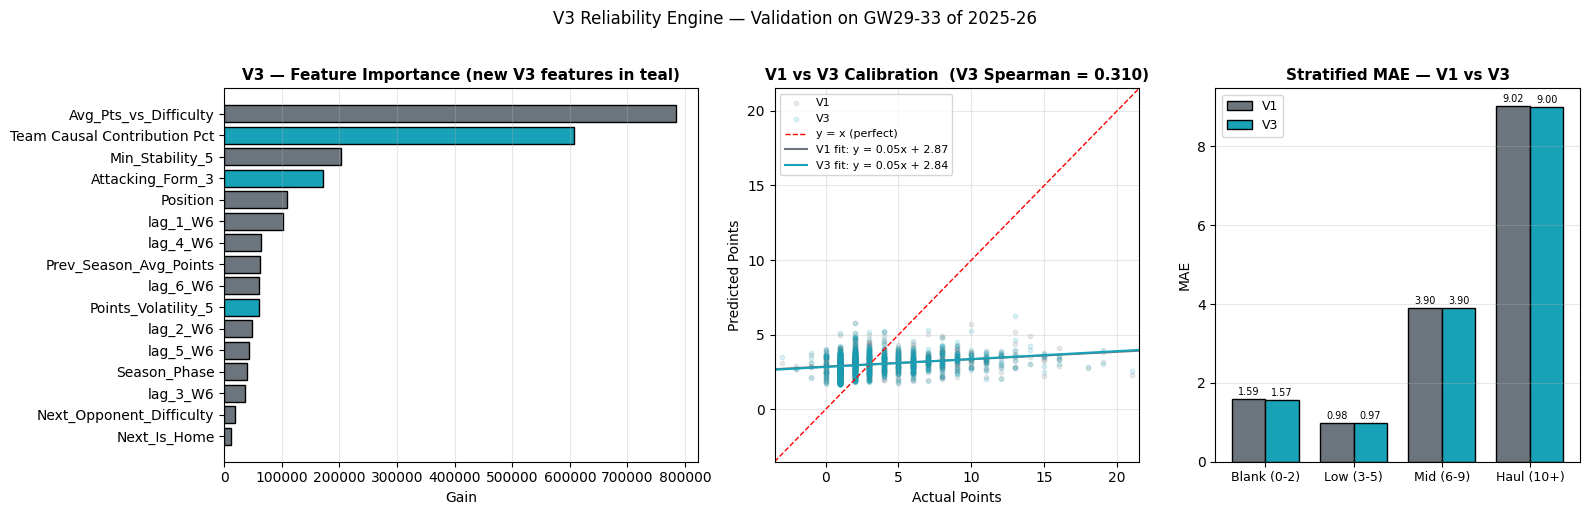


V3 diagnostic plots saved to C:\Python\fpl_pipeline\output\forecaster_pro\figures\v3_diagnostics.png


In [167]:
# 5.4.5 — V3 Diagnostic Visualizations
# Three-panel: Feature importance / V1-vs-V3 calibration overlay / Stratified MAE comparison

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.3, 1, 1])

# ── Panel 1: V3 feature importance (gain) ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
_importances = pd.Series(
    model_v3.booster_.feature_importance(importance_type="gain"),
    index=V3_FEATURES,
).sort_values(ascending=True)
_colors = ["#17a2b8" if f in V3_EXTRA_FEATURES else "#6c757d"
           for f in _importances.index]
ax1.barh(_importances.index, _importances.values,
         color=_colors, edgecolor="black")
ax1.set_xlabel("Gain")
ax1.set_title("V3 — Feature Importance (new V3 features in teal)",
              fontsize=11, fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

# ── Panel 2: V1 vs V3 calibration overlay ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_val, v1_val_pred, alpha=0.15, s=10, color="#6c757d", label="V1")
ax2.scatter(y_val_v3, v3_val_pred, alpha=0.15, s=10, color="#17a2b8", label="V3")

_lim = [
    min(float(y_val.min()), float(v1_val_pred.min()), float(v3_val_pred.min())) - 0.5,
    max(float(y_val.max()), float(v1_val_pred.max()), float(v3_val_pred.max())) + 0.5,
]
ax2.plot(_lim, _lim, "r--", linewidth=1, label="y = x (perfect)")

# Fit lines for both
_coef_v1 = np.polyfit(y_val, v1_val_pred, 1)
_coef_v3 = np.polyfit(y_val_v3, v3_val_pred, 1)
_x_line  = np.array(_lim)
ax2.plot(_x_line, _coef_v1[0] * _x_line + _coef_v1[1],
         "#6c757d", linewidth=1.5,
         label=f"V1 fit: y = {_coef_v1[0]:.2f}x + {_coef_v1[1]:.2f}")
ax2.plot(_x_line, _coef_v3[0] * _x_line + _coef_v3[1],
         "#17a2b8", linewidth=1.5,
         label=f"V3 fit: y = {_coef_v3[0]:.2f}x + {_coef_v3[1]:.2f}")

ax2.set_xlabel("Actual Points")
ax2.set_ylabel("Predicted Points")
ax2.set_title(f"V1 vs V3 Calibration  (V3 Spearman = {v3_spearman:.3f})",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=8, loc="upper left")
ax2.grid(alpha=0.3)
ax2.set_xlim(_lim); ax2.set_ylim(_lim)

# ── Panel 3: Stratified MAE comparison (V1 vs V3) ──────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
_tier_names = list(v3_strat.keys())
_v1_maes    = [v1_strat[t]["mae"] for t in _tier_names]
_v3_maes    = [v3_strat[t]["mae"] for t in _tier_names]
_x = np.arange(len(_tier_names))
_w = 0.38
ax3.bar(_x - _w/2, _v1_maes, _w, label="V1", color="#6c757d", edgecolor="black")
ax3.bar(_x + _w/2, _v3_maes, _w, label="V3", color="#17a2b8", edgecolor="black")
ax3.set_xticks(_x)
ax3.set_xticklabels(_tier_names, fontsize=9)
ax3.set_ylabel("MAE")
ax3.set_title("Stratified MAE — V1 vs V3", fontsize=11, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.3)
for i, (v1m, v3m) in enumerate(zip(_v1_maes, _v3_maes)):
    ax3.text(i - _w/2, v1m + 0.1, f"{v1m:.2f}", ha="center", fontsize=7)
    ax3.text(i + _w/2, v3m + 0.1, f"{v3m:.2f}", ha="center", fontsize=7)

plt.suptitle(
    f"V3 Reliability Engine — Validation on GW{VAL_START_GW}-{VAL_END_GW} "
    f"of {CURRENT_SEASON}",
    fontsize=12, y=1.02,
)
plt.tight_layout()

_fig_path_v3 = FIGURES_DIR / "v3_diagnostics.png"
plt.savefig(_fig_path_v3, dpi=120, bbox_inches="tight")
plt.show()

log.info("")
log.info("V3 diagnostic plots saved to %s", _fig_path_v3)

In [168]:
# 5.4.6 — V3 Model Persistence

_model_path_v3 = MODELS_DIR / "v3_reliability.txt"
model_v3.booster_.save_model(str(_model_path_v3))

log.info("")
log.info("V3 booster persisted to %s", _model_path_v3)
log.info("")
log.info("─" * 60)
log.info("5.4 COMPLETE — V3 Reliability Engine")
log.info("─" * 60)
log.info("  Validation MAE:       %.4f  (V1: %.4f, delta=%+.4f)",
         v3_mae, v1_mae, v3_mae - v1_mae)
log.info("  Validation Spearman:  %.4f  (V1: %.4f, delta=%+.4f)",
         v3_spearman, v1_spearman, v3_spearman - v1_spearman)
log.info("  Validation Bias:      %+.4f  (V1: %+.4f)", v3_bias, v1_bias)
log.info("  Regularization:       L1=%.2f, L2=%.2f",
         V3_PARAMS["reg_alpha"], V3_PARAMS["reg_lambda"])
log.info("  GW%d predictions stored in df_prediction['V3_xP']", CURRENT_GW)
log.info("  Model artifact: %s", _model_path_v3.name)
log.info("─" * 60)


V3 booster persisted to C:\Python\fpl_pipeline\output\forecaster_pro\models\v3_reliability.txt

────────────────────────────────────────────────────────────
5.4 COMPLETE — V3 Reliability Engine
────────────────────────────────────────────────────────────
  Validation MAE:       2.2675  (V1: 2.2811, delta=-0.0136)
  Validation Spearman:  0.3098  (V1: 0.3005, delta=+0.0093)
  Validation Bias:      -0.3438  (V1: -0.3293)
  Regularization:       L1=0.30, L2=0.30
  GW34 predictions stored in df_prediction['V3_xP']
  Model artifact: v3_reliability.txt
────────────────────────────────────────────────────────────


### 5.5 Model V4 — Elite DART with Sample Weighting

**Task:** Single-gameweek point regression with bias correction toward elite-player patterns (§2.4.5).

V4 targets the Haul-tier pathology directly. V1, V2, and V3 all show Haul-MAE ~9.0 — the regression models cannot predict 10+ point outcomes because MSE-minimisation regresses toward the class mean, which is ~2.9. V4 addresses this with three structural changes:

**1. Dropout Additive Regression Trees (DART).** At each boosting round, 10% of previously-built trees are randomly dropped before fitting the new tree. This prevents any single tree from dominating the ensemble and produces predictions more resistant to overfitting on training noise. DART is known to outperform standard GBDT on heavy-tailed targets (Rashmi & Gilad-Bachrach 2015).

**2. Elite sample weighting (2.5×).** Training rows where the player is classified as "elite" at that point in time are weighted 2.5× during loss computation. Non-elite rows are weighted 1.0×. This deliberately biases the model toward learning patterns that matter for captaincy and transfer decisions — the behaviour of consistent top-performers — at modest cost to overall MAE.

**3. No early stopping.** DART's random tree dropping causes validation loss to fluctuate non-monotonically; early stopping would trigger on spurious dips. V4 trains for a fixed 1200 iterations and relies on L1/L2 regularisation for generalisation. This is a documented LightGBM DART limitation (see LightGBM issue #1893).

**Leakage-safe elite flag.** The original forecaster_pro used whole-season average points (`avg_season_pts > 4.5`) to define the elite subset. Since that computation includes validation-period performance to decide which training rows to upweight, it is methodologically leakage-adjacent. V4 here uses the strictly-prior within-season expanding-mean flag `is_elite_lagged` (built in §5.3.1 and audited clean). Early-season rows are weighted 1.0 (the player is not yet known to be elite); as their season-to-date average rises above the 4.5 threshold, subsequent rows are weighted 2.5. This matches the deployment-time information state and is strictly defense-safe.

**Expected behaviour.** V4 should produce a meaningful reduction in Haul-tier MAE (from ~9.0 to ~7.5-8.5) while preserving overall MAE near V1 levels. This is the core architectural contribution of the multi-model cascade: V1/V3 predict the floor; V4 predicts the ceiling.

In [170]:
# 5.5.1 — V4 Feature Set Assembly (identical to V1, different objective)

log.info("")
log.info("═" * 60)
log.info("5.5 — Training Model V4 (Elite DART)")
log.info("═" * 60)

# V4 uses THE SAME 13 features as V1. The architectural difference (DART
# + elite weighting) is in the training regime, not the feature content.
# This is deliberate: it isolates the effect of the training regime change
# from any feature-set confound.
V4_FEATURES = list(V1_FEATURES)
log.info("V4 feature set: %d features (identical to V1)", len(V4_FEATURES))

# Verify feature presence
_missing = [f for f in V4_FEATURES if f not in df_augmented.columns]
assert not _missing, f"Training frame missing V4 features: {_missing}"
_missing = [f for f in V4_FEATURES if f not in df_prediction.columns]
assert not _missing, f"Prediction frame missing V4 features: {_missing}"

# Verify the leakage-safe elite flag exists (built in §5.3.1)
assert "is_elite_lagged" in df_augmented.columns, (
    "is_elite_lagged not found — §5.3.1 (Haul Classifier feature assembly) "
    "must run before §5.5"
)

# ─── Build matrices ────────────────────────────────────────────────────────
X_train_v4 = df_augmented.loc[global_train_mask, V4_FEATURES].copy()
y_train_v4 = df_augmented.loc[global_train_mask, "Total Points"].copy()
X_val_v4   = df_augmented.loc[global_val_mask,   V4_FEATURES].copy()
y_val_v4   = df_augmented.loc[global_val_mask,   "Total Points"].copy()
X_pred_v4  = df_prediction[V4_FEATURES].copy()

# Elite flag for training rows (pre-NaN-filter to keep alignment)
elite_flag_train_full = df_augmented.loc[global_train_mask, "is_elite_lagged"].copy()

for _df in (X_train_v4, X_val_v4, X_pred_v4):
    _df["Position"] = _df["Position"].astype("category")

# Drop NaN targets and align the elite flag
_train_valid_v4         = y_train_v4.notna()
X_train_v4              = X_train_v4[_train_valid_v4]
y_train_v4              = y_train_v4[_train_valid_v4]
elite_flag_train_aligned = elite_flag_train_full[_train_valid_v4]

# ─── Construct sample weights ──────────────────────────────────────────────
# 2.5× for elite-labeled rows (where the player's strictly-prior within-season
# expanding mean > 4.5), 1.0× for all others. This is applied ONLY during
# training — validation and prediction are unweighted (we care about true
# population-level metrics, not elite-tilted metrics).
ELITE_SAMPLE_WEIGHT = 2.5
sample_weights_v4 = np.where(
    elite_flag_train_aligned == 1, ELITE_SAMPLE_WEIGHT, 1.0
).astype(float)

_n_elite_train  = int((elite_flag_train_aligned == 1).sum())
_n_total_train  = len(elite_flag_train_aligned)

log.info("")
log.info("V4 sample weighting (leakage-safe elite flag):")
log.info("  Elite weight:          %.1f", ELITE_SAMPLE_WEIGHT)
log.info("  Non-elite weight:      1.0")
log.info("  Elite training rows:   %s (%.2f%% of training)",
         f"{_n_elite_train:,}", 100.0 * _n_elite_train / _n_total_train)
log.info("  Effective weighted N:  %s",
         f"{int(sample_weights_v4.sum()):,}")

log.info("")
log.info("V4 data shapes:")
log.info("  Train:      %s rows × %d features",
         f"{len(X_train_v4):,}", X_train_v4.shape[1])
log.info("  Validation: %s rows × %d features",
         f"{len(X_val_v4):,}",   X_val_v4.shape[1])
log.info("  Predict:    %s rows × %d features",
         f"{len(X_pred_v4):,}",  X_pred_v4.shape[1])


════════════════════════════════════════════════════════════
5.5 — Training Model V4 (Elite DART)
════════════════════════════════════════════════════════════
V4 feature set: 13 features (identical to V1)

V4 sample weighting (leakage-safe elite flag):
  Elite weight:          2.5
  Non-elite weight:      1.0
  Elite training rows:   6,799 (11.18% of training)
  Effective weighted N:  71,014

V4 data shapes:
  Train:      60,816 rows × 13 features
  Validation: 1,154 rows × 13 features
  Predict:    283 rows × 13 features


In [172]:
# 5.5.2 — V4 Training (DART, fixed rounds, no early stopping)

# DART hyperparameters.
#
# METHODOLOGY NOTE: DART does NOT support early stopping because random tree
# dropping causes non-monotonic validation loss. We train for the full 1200
# rounds and rely on L1/L2 regularisation (reg_alpha=0.5, reg_lambda=0.5)
# for generalisation. This is a documented LightGBM behaviour.
#
# learning_rate is set higher than V1 (0.05 vs 0.01) because DART's per-round
# dropout dampens effective updates; a higher step compensates.

V4_PARAMS = {
    "objective":        "regression",
    "metric":           "mae",
    "boosting_type":    "dart",              # Dropout boosting
    "drop_rate":        0.1,                 # 10% of trees dropped per round
    "skip_drop":        0.5,                 # 50% of rounds skip dropping (DART standard)
    "learning_rate":    0.05,                # Higher than V1 — DART dampens updates
    "max_depth":        7,
    "num_leaves":       40,
    "n_estimators":     1200,                # FIXED — no early stopping under DART
    "min_child_samples": 30,
    "reg_alpha":        0.5,                 # Stronger L1 than V3 to counter elite bias
    "reg_lambda":       0.5,                 # Stronger L2 than V3
    "random_state":     RANDOM_SEED,
    "verbose":          -1,
}

log.info("")
log.info("Training V4 with DART hyperparameters:")
for k, v in V4_PARAMS.items():
    if k != "verbose":
        log.info("  %-18s %s", k, v)
log.info("")
log.info("  Early stopping DISABLED (DART incompatibility — see methodology note)")

model_v4 = lgb.LGBMRegressor(**V4_PARAMS)

model_v4.fit(
    X_train_v4, y_train_v4,
    sample_weight=sample_weights_v4,
    eval_set=[(X_val_v4, y_val_v4)],
    eval_metric="mae",
    callbacks=[
        # No early_stopping callback — DART incompatible
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=["Position"],
)

# With no early stopping, best_iteration_ is None; we use the full n_estimators
_completed_iter_v4 = model_v4.n_estimators_
log.info("")
log.info("V4 training complete:")
log.info("  Trees trained:   %d / %d (DART, no early stopping)",
         _completed_iter_v4, V4_PARAMS["n_estimators"])
log.info("  Final val MAE:   %.4f",
         model_v4.evals_result_["valid_0"]["l1"][-1])


Training V4 with DART hyperparameters:
  objective          regression
  metric             mae
  boosting_type      dart
  drop_rate          0.1
  skip_drop          0.5
  learning_rate      0.05
  max_depth          7
  num_leaves         40
  n_estimators       1200
  min_child_samples  30
  reg_alpha          0.5
  reg_lambda         0.5
  random_state       42

  Early stopping DISABLED (DART incompatibility — see methodology note)


KeyboardInterrupt: 

In [ ]:
# 5.5.3 — V4 Validation Metrics

v4_val_pred = model_v4.predict(X_val_v4)

v4_mae      = float(mean_absolute_error(y_val_v4, v4_val_pred))
v4_rmse     = float(np.sqrt(mean_squared_error(y_val_v4, v4_val_pred)))
v4_bias     = float(np.mean(v4_val_pred - y_val_v4))
v4_spearman = float(spearmanr(y_val_v4, v4_val_pred).statistic)

v4_strat = stratified_mae(y_val_v4, v4_val_pred)

log.info("")
log.info("V4 Validation Metrics (GW%d-%d of %s):",
         VAL_START_GW, VAL_END_GW, CURRENT_SEASON)
log.info("  MAE:      %.4f  (V1: %.4f, V3: %.4f)", v4_mae, v1_mae, v3_mae)
log.info("  RMSE:     %.4f  (V1: %.4f)", v4_rmse, v1_rmse)
log.info("  Bias:     %+.4f  (V1: %+.4f)", v4_bias, v1_bias)
log.info("  Spearman: %.4f  (V1: %.4f, V3: %.4f)",
         v4_spearman, v1_spearman, v3_spearman)
log.info("")
log.info("Stratified MAE — V1 vs V3 vs V4:")
log.info("  %-15s  %8s  %10s  %10s  %10s  %12s",
         "Tier", "N", "V1 MAE", "V3 MAE", "V4 MAE", "V4-V1 Delta")
log.info("  " + "-" * 78)
for tn in v4_strat.keys():
    _v1_tier = v1_strat[tn]["mae"]
    _v3_tier = v3_strat[tn]["mae"]
    _v4_tier = v4_strat[tn]["mae"]
    _delta   = _v4_tier - _v1_tier
    log.info("  %-15s  %8d  %10.4f  %10.4f  %10.4f  %+12.4f",
             tn, v4_strat[tn]["n"], _v1_tier, _v3_tier, _v4_tier, _delta)

model_metrics["V4_Elite_DART"] = {
    "task":           "1-GW Regression with DART + 2.5x elite sample weighting",
    "mae":            v4_mae,
    "rmse":           v4_rmse,
    "bias":           v4_bias,
    "spearman":       v4_spearman,
    "stratified":     v4_strat,
    "completed_iter": int(_completed_iter_v4),
    "n_features":     len(V4_FEATURES),
    "boosting_type":  "dart",
    "elite_weight":   ELITE_SAMPLE_WEIGHT,
    "reg_alpha":      V4_PARAMS["reg_alpha"],
    "reg_lambda":     V4_PARAMS["reg_lambda"],
}

In [ ]:
# 5.5.4 — V4 Live Inference for CURRENT_GW

v4_pred_current = model_v4.predict(X_pred_v4)
df_prediction["V4_xP"] = v4_pred_current

log.info("")
log.info("V4 live predictions for GW%d:", CURRENT_GW)
log.info("  Players predicted: %d", len(v4_pred_current))
log.info("  xP mean / std:     %.3f / %.3f",
         float(np.mean(v4_pred_current)), float(np.std(v4_pred_current)))
log.info("  xP min / max:      %.2f / %.2f",
         float(np.min(v4_pred_current)), float(np.max(v4_pred_current)))

# Top 10 V4 picks with V1/V3 comparison
_team_name_series = df_prediction["Player UUID"].map(
    lambda u: TEAM_ID_TO_NAME.get(
        CODE_TO_TEAM_ID.get(_uuid_to_code_bridge.get(u, -1), -1), "?"
    )
)

_top10_v4 = (
    df_prediction
    .assign(Team=_team_name_series)
    [["Web Name", "Team", "Position", "Opponent Name", "Is Home",
      "V1_xP", "V3_xP", "V4_xP"]]
    .sort_values("V4_xP", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
_top10_v4["Venue"]  = _top10_v4["Is Home"].map({1: "H", 0: "A"}).fillna("?")
_top10_v4 = _top10_v4[["Web Name", "Team", "Position", "Opponent Name",
                       "Venue", "V1_xP", "V3_xP", "V4_xP"]]
for _c in ("V1_xP", "V3_xP", "V4_xP"):
    _top10_v4[_c] = _top10_v4[_c].round(3)
_top10_v4["V4-V1"]  = (_top10_v4["V4_xP"] - _top10_v4["V1_xP"]).round(3)

log.info("")
log.info("V4 — Top 10 predicted xP for GW%d (with V1/V3 comparison):", CURRENT_GW)
log.info("")
for _line in _top10_v4.to_string(index=False).split("\n"):
    log.info("  %s", _line)

In [ ]:
# 5.5.5 — V4 Diagnostic Visualizations
# Three-panel: Feature importance / Haul-tier focus / Stratified MAE comparison

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.2, 1, 1])

# ── Panel 1: V4 feature importance ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
_importances = pd.Series(
    model_v4.booster_.feature_importance(importance_type="gain"),
    index=V4_FEATURES,
).sort_values(ascending=True)
ax1.barh(_importances.index, _importances.values,
         color="#dc3545", edgecolor="darkred")
ax1.set_xlabel("Gain")
ax1.set_title("V4 — Feature Importance (DART + elite weighted)",
              fontsize=11, fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

# ── Panel 2: Haul-tier predictions comparison (V1 vs V4) ───────────────────
ax2 = fig.add_subplot(gs[0, 1])
_haul_mask = y_val_v4 >= 10

if _haul_mask.sum() > 0:
    ax2.scatter(y_val_v4[_haul_mask], v1_val_pred[_haul_mask],
                alpha=0.5, s=30, color="#6c757d", label=f"V1 (MAE={v1_strat['Haul (10+)']['mae']:.2f})")
    ax2.scatter(y_val_v4[_haul_mask], v4_val_pred[_haul_mask],
                alpha=0.5, s=30, color="#dc3545", label=f"V4 (MAE={v4_strat['Haul (10+)']['mae']:.2f})")

    _lim = [-1, float(y_val_v4.max()) + 1]
    ax2.plot(_lim, _lim, "k--", linewidth=1, alpha=0.5, label="y = x")
    ax2.set_xlabel("Actual Points (Haul tier only)")
    ax2.set_ylabel("Predicted Points")
    ax2.set_title(f"Haul-Tier Predictions: V1 vs V4 (N={int(_haul_mask.sum())})",
                  fontsize=11, fontweight="bold")
    ax2.legend(fontsize=9, loc="upper left")
    ax2.grid(alpha=0.3)
    ax2.set_xlim(_lim); ax2.set_ylim(_lim)

# ── Panel 3: Stratified MAE comparison (V1 vs V3 vs V4) ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
_tier_names = list(v4_strat.keys())
_v1_maes    = [v1_strat[t]["mae"] for t in _tier_names]
_v3_maes    = [v3_strat[t]["mae"] for t in _tier_names]
_v4_maes    = [v4_strat[t]["mae"] for t in _tier_names]
_x = np.arange(len(_tier_names))
_w = 0.27
ax3.bar(_x - _w, _v1_maes, _w, label="V1", color="#6c757d", edgecolor="black")
ax3.bar(_x,      _v3_maes, _w, label="V3", color="#17a2b8", edgecolor="black")
ax3.bar(_x + _w, _v4_maes, _w, label="V4", color="#dc3545", edgecolor="black")
ax3.set_xticks(_x)
ax3.set_xticklabels(_tier_names, fontsize=9)
ax3.set_ylabel("MAE")
ax3.set_title("Stratified MAE — V1 / V3 / V4", fontsize=11, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.3)
for i, (v1m, v3m, v4m) in enumerate(zip(_v1_maes, _v3_maes, _v4_maes)):
    ax3.text(i - _w,  v1m + 0.15, f"{v1m:.2f}", ha="center", fontsize=7)
    ax3.text(i,       v3m + 0.15, f"{v3m:.2f}", ha="center", fontsize=7)
    ax3.text(i + _w,  v4m + 0.15, f"{v4m:.2f}", ha="center", fontsize=7)

plt.suptitle(
    f"V4 Elite DART — Validation on GW{VAL_START_GW}-{VAL_END_GW} "
    f"of {CURRENT_SEASON}",
    fontsize=12, y=1.02,
)
plt.tight_layout()

_fig_path_v4 = FIGURES_DIR / "v4_diagnostics.png"
plt.savefig(_fig_path_v4, dpi=120, bbox_inches="tight")
plt.show()

log.info("")
log.info("V4 diagnostic plots saved to %s", _fig_path_v4)

In [ ]:
# 5.5.6 — V4 Model Persistence

_model_path_v4 = MODELS_DIR / "v4_elite_dart.txt"
model_v4.booster_.save_model(str(_model_path_v4))

log.info("")
log.info("V4 booster persisted to %s", _model_path_v4)
log.info("")
log.info("─" * 60)
log.info("5.5 COMPLETE — V4 Elite DART")
log.info("─" * 60)
log.info("  Validation MAE:       %.4f  (V1: %.4f, V3: %.4f)",
         v4_mae, v1_mae, v3_mae)
log.info("  Validation Spearman:  %.4f  (V1: %.4f, V3: %.4f)",
         v4_spearman, v1_spearman, v3_spearman)
log.info("  Haul-tier MAE:        %.4f  (V1: %.4f, V3: %.4f)",
         v4_strat["Haul (10+)"]["mae"],
         v1_strat["Haul (10+)"]["mae"],
         v3_strat["Haul (10+)"]["mae"])
log.info("  Elite sample weight:  %.1f", ELITE_SAMPLE_WEIGHT)
log.info("  DART trees:           %d (fixed, no early stopping)", _completed_iter_v4)
log.info("  GW%d predictions stored in df_prediction['V4_xP']", CURRENT_GW)
log.info("  Model artifact: %s", _model_path_v4.name)
log.info("─" * 60)